# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [88]:
import pandas as pd

data = pd.read_csv("auto_dataset.csv")
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [89]:
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

X_data = data.drop('price', axis=1)
y_data = data['price']
X_train, X_te, y_train, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_te, y_te, test_size=0.5, random_state=42)

X_data = data.drop('price', axis=1)
y_data = data['price']
X_train, X_te, y_train, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_te, y_te, test_size=0.5, random_state=42)


encoder = TargetEncoder(cols=['brand','model'], smoothing=10.0)

X_train[['brand','model']] = encoder.fit_transform(X_train[['brand','model']], y_train)
X_test[['brand','model']] = encoder.transform(X_test[['brand','model']])
X_val[['brand','model']] = encoder.transform(X_val[['brand','model']])

X_train = pd.get_dummies(X_train, columns=['vehicleType','fuelType','gearbox'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['vehicleType','fuelType','gearbox'], drop_first=True, dtype=int)
X_val = pd.get_dummies(X_val, columns=['vehicleType','fuelType','gearbox'], drop_first=True, dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

repair = {
    "ja" : 0,
    "nein" : 1
}
X_train['notRepairedDamage'] = X_train['notRepairedDamage'].map(repair)
X_test['notRepairedDamage'] = X_test['notRepairedDamage'].map(repair)
X_val['notRepairedDamage'] = X_val['notRepairedDamage'].map(repair)

3. Разбейте датасет на train val test в отношении 8:1:1

In [ ]:
# X_data = data.drop('price', axis=1)
# y_data = data['price']
# X_train, X_te, y_train, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# X_val, X_test, y_val, y_test = train_test_split(X_te, y_te, test_size=0.5, random_state=42)

# X_data = data.drop('price', axis=1)
# y_data = data['price']
# X_train, X_te, y_train, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# X_val, X_test, y_val, y_test = train_test_split(X_te, y_te, test_size=0.5, random_state=42)



4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

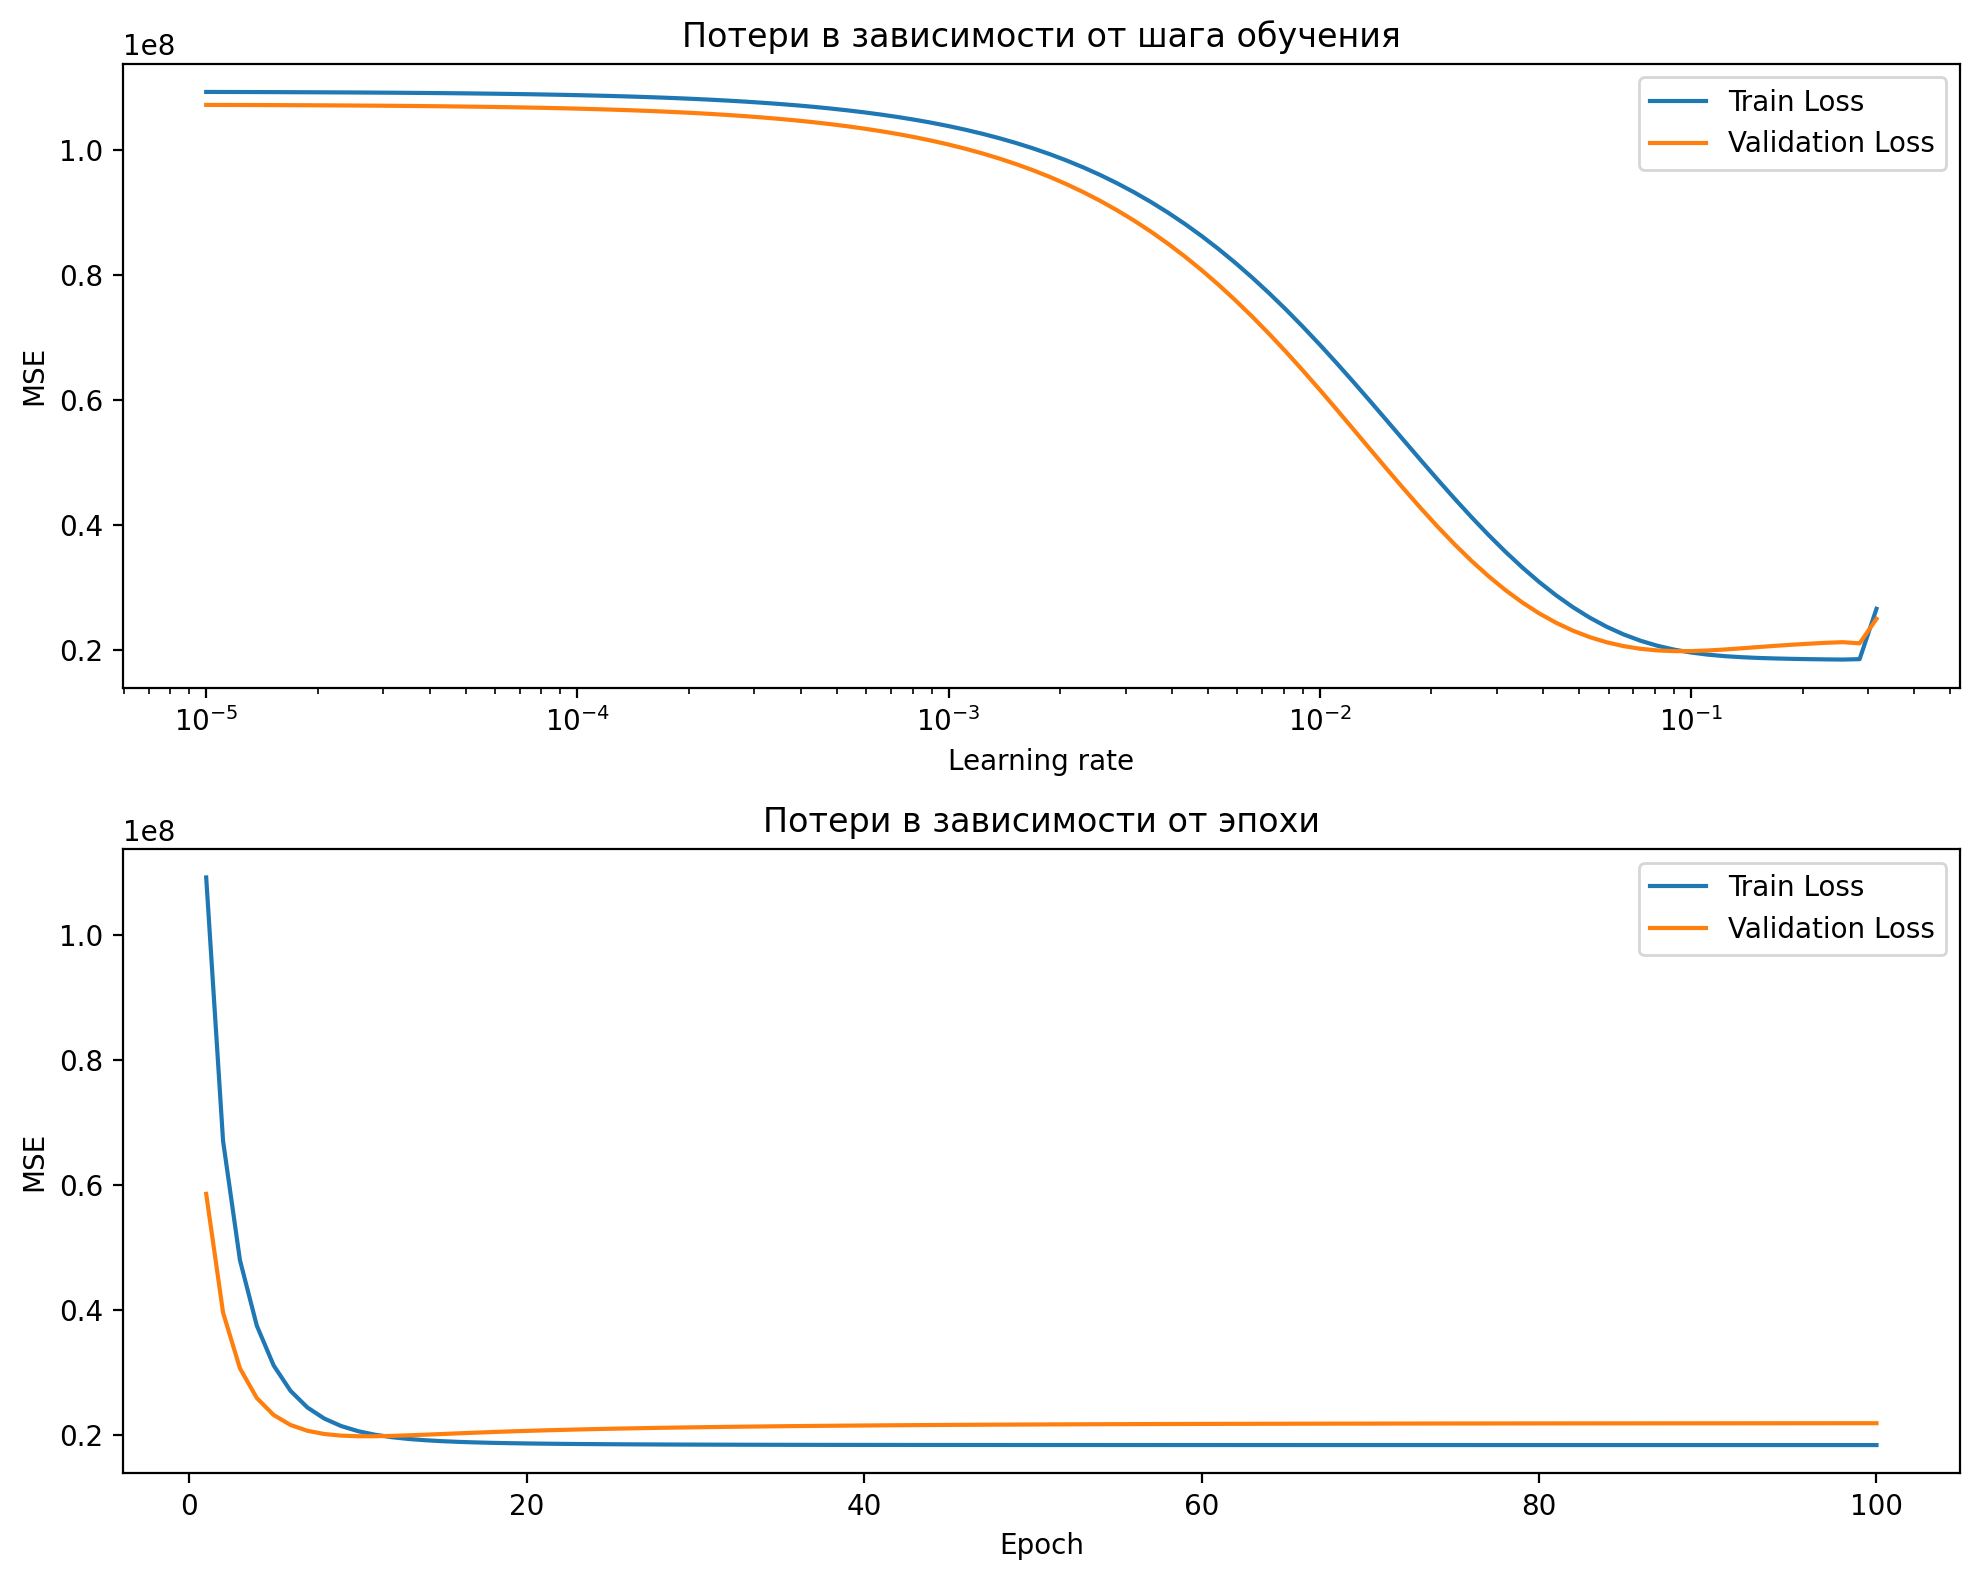

Лучший шаг: 0.09006280202112786
R2 на тестовой выборке: 0.6199
Loss на тестовой выборке: 26504954.9443
Оптимальное количество эпох: 17


In [102]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -0.5, 100)


class VanillaLinearRegression:
    def __init__(self, features, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = torch.zeros(
            features, 1,
            requires_grad=True,
            dtype=torch.float64
        )
        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            mse = torch.mean((y_pred - y) ** 2)

            mse.backward()

            with torch.no_grad():
                self.weights -= self.learning_rate * self.weights.grad
                self.bias -= self.learning_rate * self.bias.grad

                self.weights.grad.zero_()
                self.bias.grad.zero_()

            self.loss_history.append(mse.item())

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)
                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = VanillaLinearRegression(
        learning_rate=lyamda,
        epochs=10,
        features=X_train.shape[1]
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]

vanilla_model = VanillaLinearRegression(
    learning_rate=best_lyamda,
    epochs=100,
    features=X_train.shape[1]
)

vanilla_model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].set_title("Потери в зависимости от шага обучения")
ax[0].legend()


ax[1].plot(
    range(1, vanilla_model.epochs + 1),
    vanilla_model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, vanilla_model.epochs + 1),
    vanilla_model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Потери в зависимости от эпохи")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")

print(f"R2 на тестовой выборке: {r2_score(y_test, vanilla_model.predict(X_test)):.4f}")
print(f"Loss на тестовой выборке: {mean_squared_error(y_test, vanilla_model.predict(X_test)):.4f}")
print(f"Оптимальное количество эпох: {17}")



5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

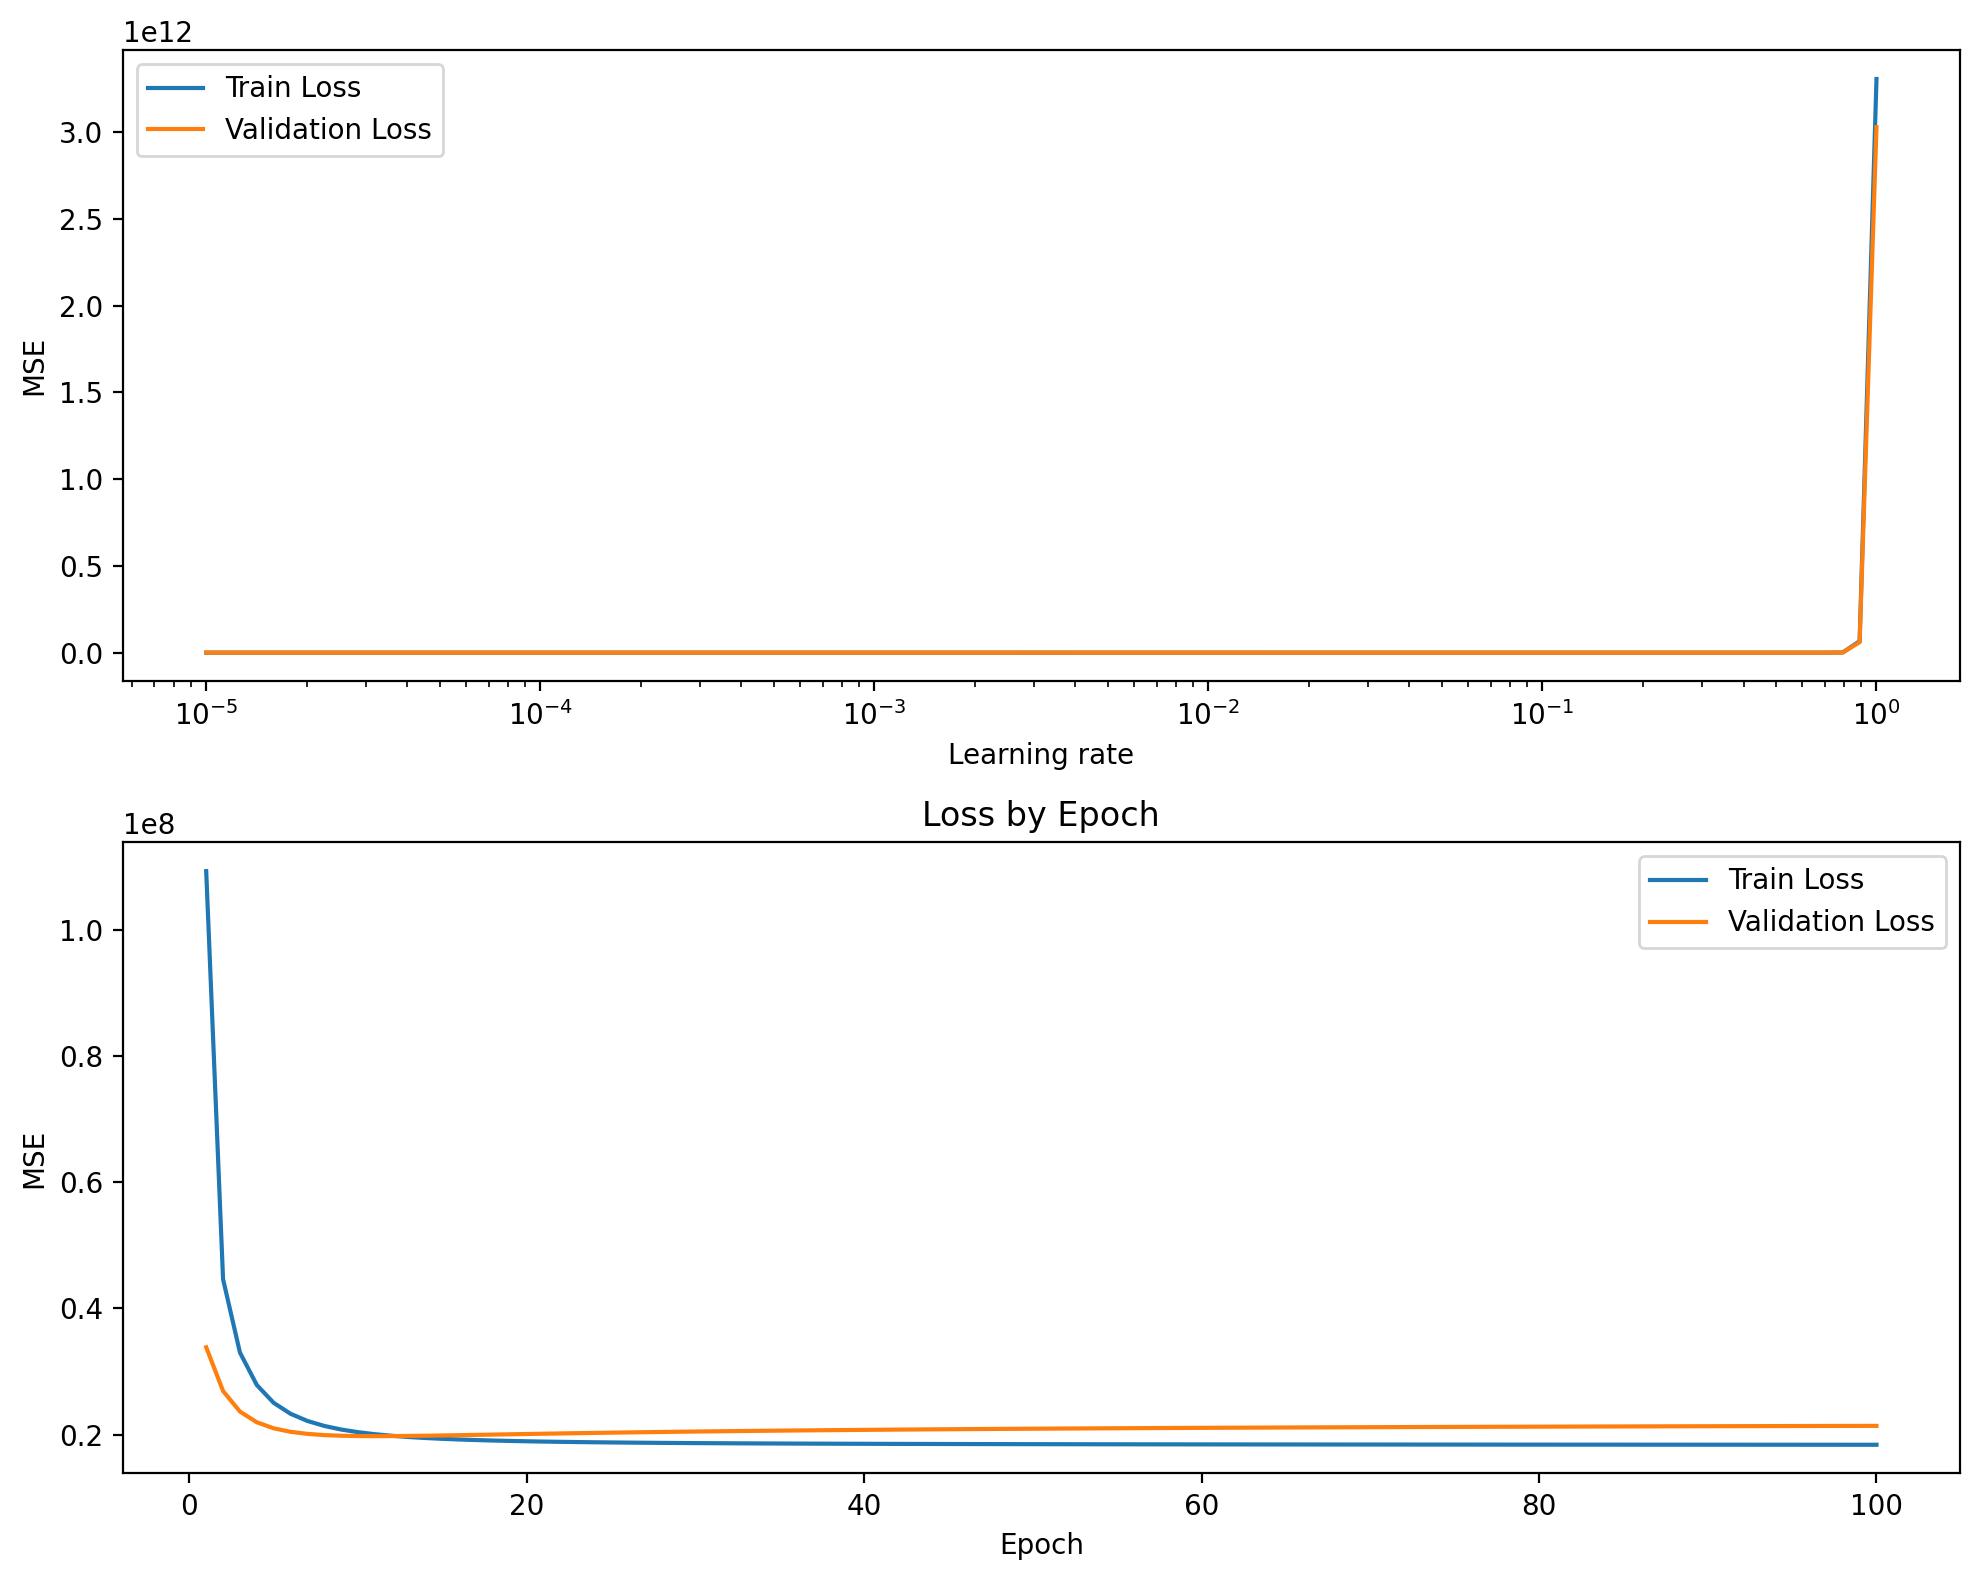

Лучший шаг: 0.1747528400007683
R2 на тестовой выборке: 0.6129
Loss на тестовой выборке: 26993667.1190
Оптимальное количество эпох: 23


In [103]:
class VanillaLinearRegressionTimeLr:
    def __init__(self, features, learning_rate=0.01, epochs=100, s=1, p=0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = torch.zeros(features, 1, requires_grad=True, dtype=torch.float64)
        self.bias = torch.zeros(1, requires_grad=True, dtype=torch.float64)
        self.s = s
        self.p = p
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            mse = torch.mean((y_pred - y) ** 2)

            mse.backward()

            with torch.no_grad():
                lr_factor = (self.s / (self.s + epoch)) ** self.p

                self.weights -= self.learning_rate * self.weights.grad * lr_factor
                self.bias -= self.learning_rate * self.bias.grad * lr_factor

                self.weights.grad.zero_()
                self.bias.grad.zero_()

            self.loss_history.append(mse.item())

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)
                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


lyamdas = np.logspace(-5, 0, 100)
losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = VanillaLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=10,
        features=X_train.shape[1],
        s=1,
        p=0.5
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]

vanilla_timelr_model = VanillaLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=100,
    features=X_train.shape[1],
    s=1,
    p=0.5
)

vanilla_timelr_model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].legend()


ax[1].plot(
    range(1, vanilla_timelr_model.epochs + 1),
    vanilla_timelr_model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, vanilla_timelr_model.epochs + 1),
    vanilla_timelr_model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Loss by Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")

print(f"R2 на тестовой выборке: {r2_score(y_test, vanilla_timelr_model.predict(X_test)):.4f}")
print(f"Loss на тестовой выборке: {mean_squared_error(y_test, vanilla_timelr_model.predict(X_test)):.4f}")
print(f"Оптимальное количество эпох: {23}")


6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

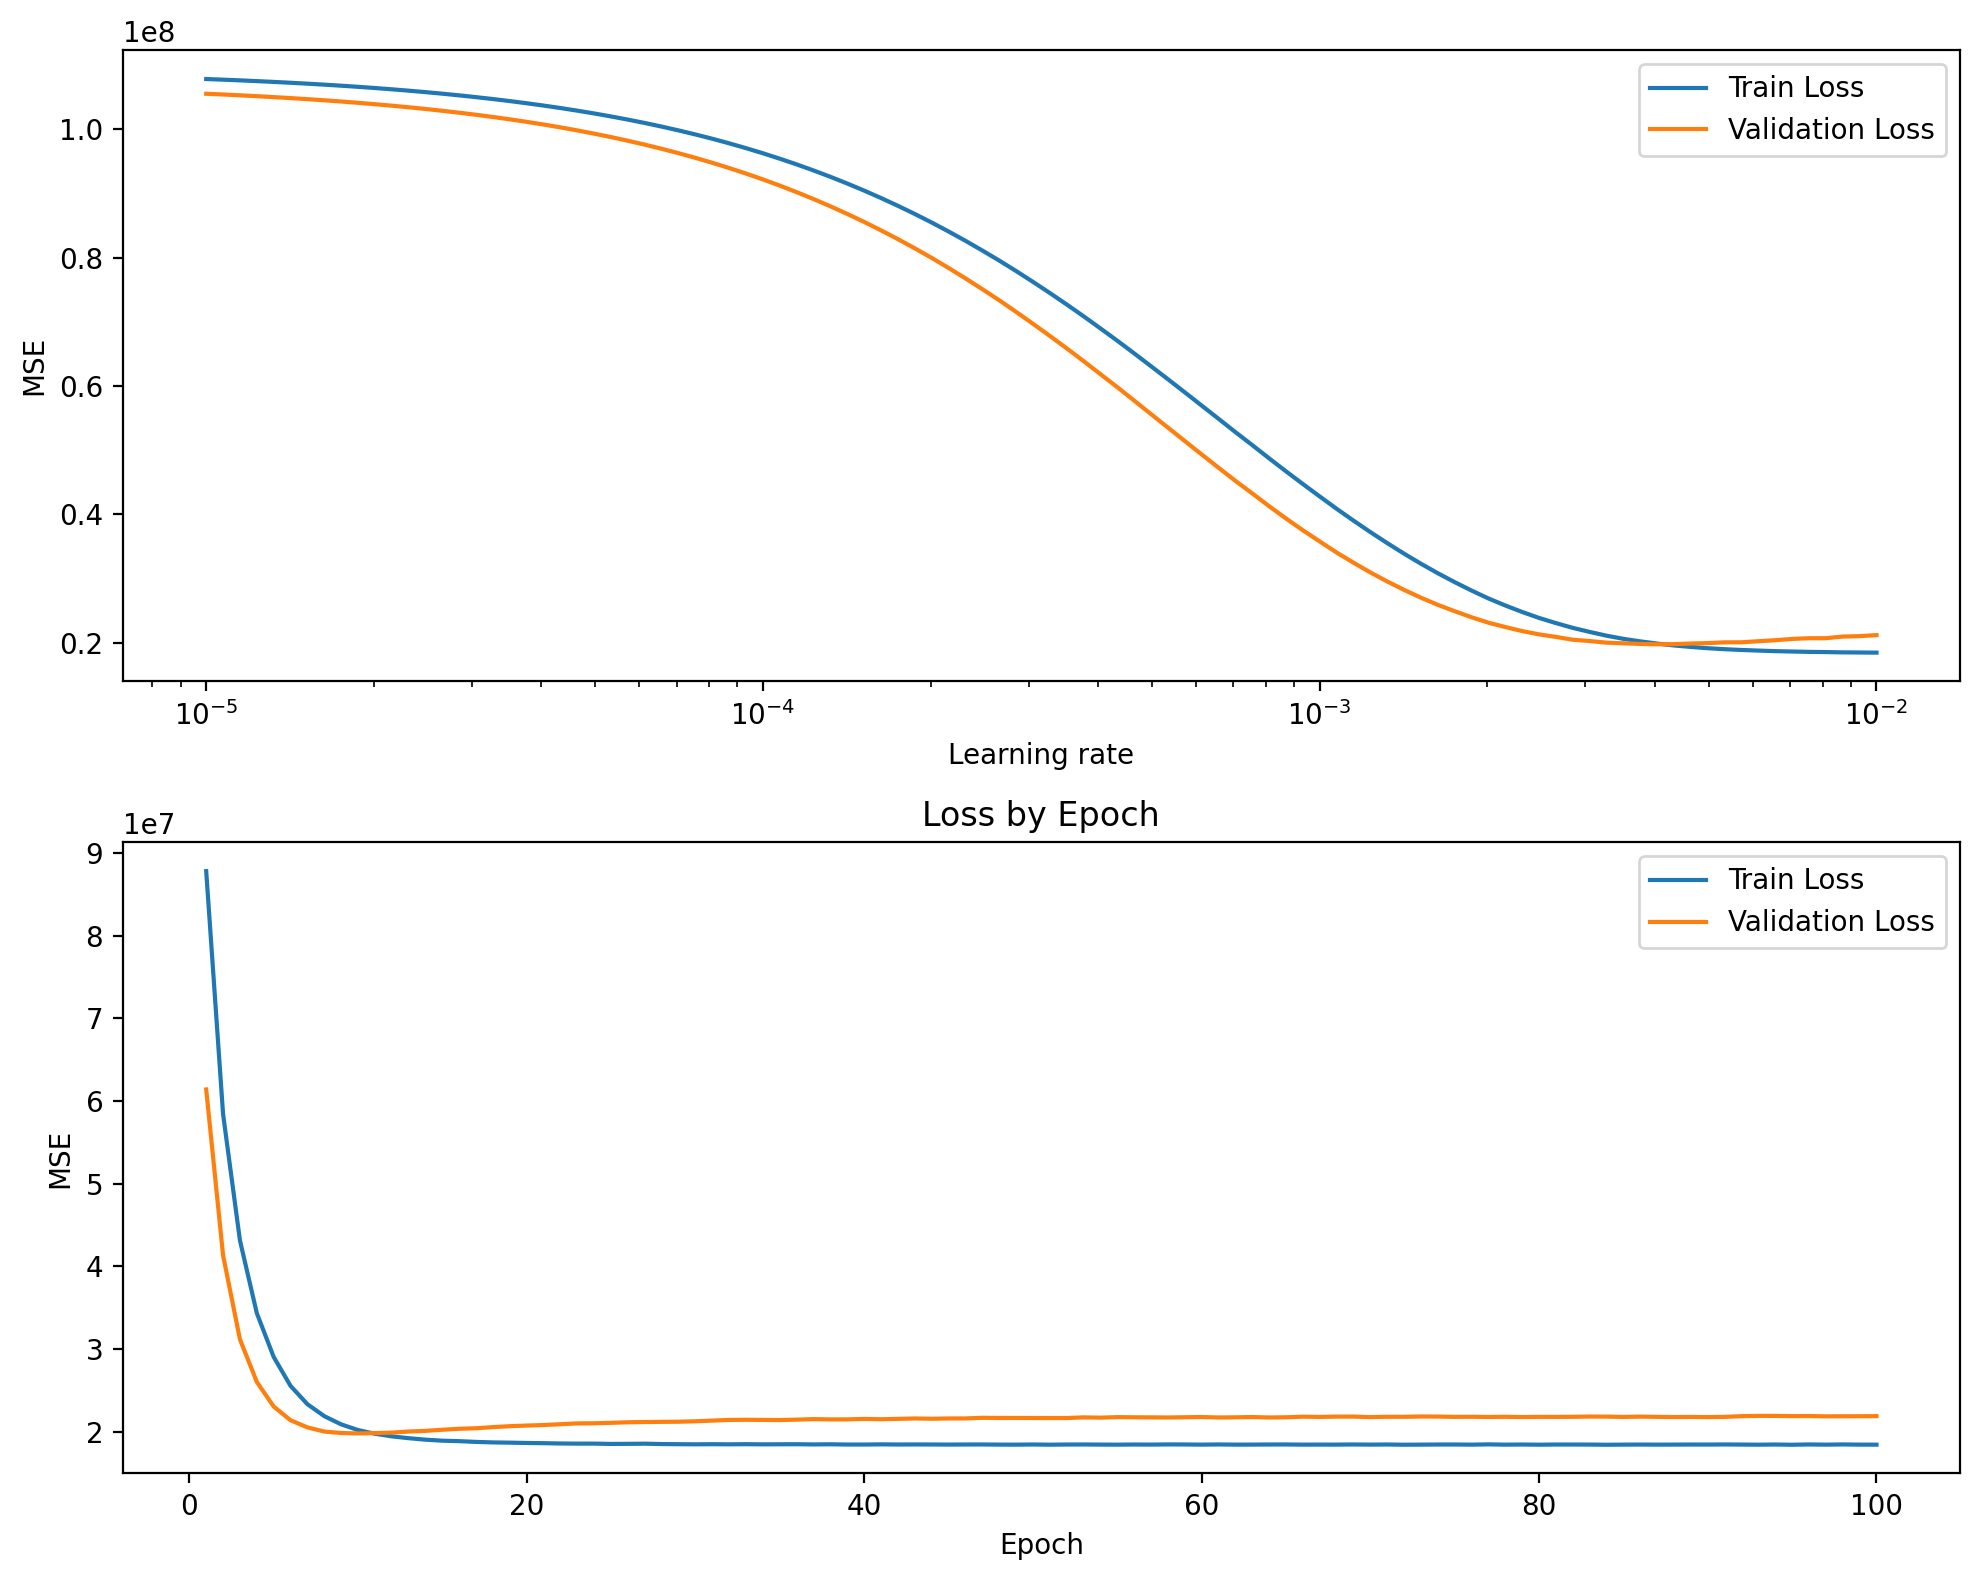

Лучший шаг: 0.004037017258596553
R2 на тестовой выборке: 0.6204
Loss на тестовой выборке: 26474709.8398
Оптимальное количество эпох: 12


In [104]:
import torch
import numpy as np

class SGDLinearRegression:
    def __init__(self, features, learning_rate=0.01, epochs=100, batch_size=32):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = torch.zeros(features, 1, requires_grad=True, dtype=torch.float64)
        self.bias = torch.zeros(1, requires_grad=True, dtype=torch.float64)
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        num_samples = X.shape[0]
        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            indices = torch.randperm(num_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for i in range(0, num_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                y_batch = y_shuffled[i : i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias
                mse = torch.mean((y_pred - y_batch) ** 2)

                mse.backward()

                with torch.no_grad():
                    self.weights -= self.learning_rate * self.weights.grad
                    self.bias -= self.learning_rate * self.bias.grad
                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(mse.item())

            self.loss_history.append(np.mean(epoch_losses))

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)
                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


lyamdas = np.logspace(-5, -2, 100)
losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = SGDLinearRegression(
        learning_rate=lyamda,
        epochs=10,
        features=X_train.shape[1],
        batch_size=32
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]

sgd_model = SGDLinearRegression(
    learning_rate=best_lyamda,
    epochs=100,
    features=X_train.shape[1],
    batch_size=32
)

sgd_model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].legend()


ax[1].plot(
    range(1, sgd_model.epochs + 1),
    sgd_model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, sgd_model.epochs + 1),
    sgd_model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Loss by Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")

print(f"R2 на тестовой выборке: {r2_score(y_test, sgd_model.predict(X_test)):.4f}")
print(f"Loss на тестовой выборке: {mean_squared_error(y_test, sgd_model.predict(X_test)):.4f}")
print(f"Оптимальное количество эпох: {12}")



7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

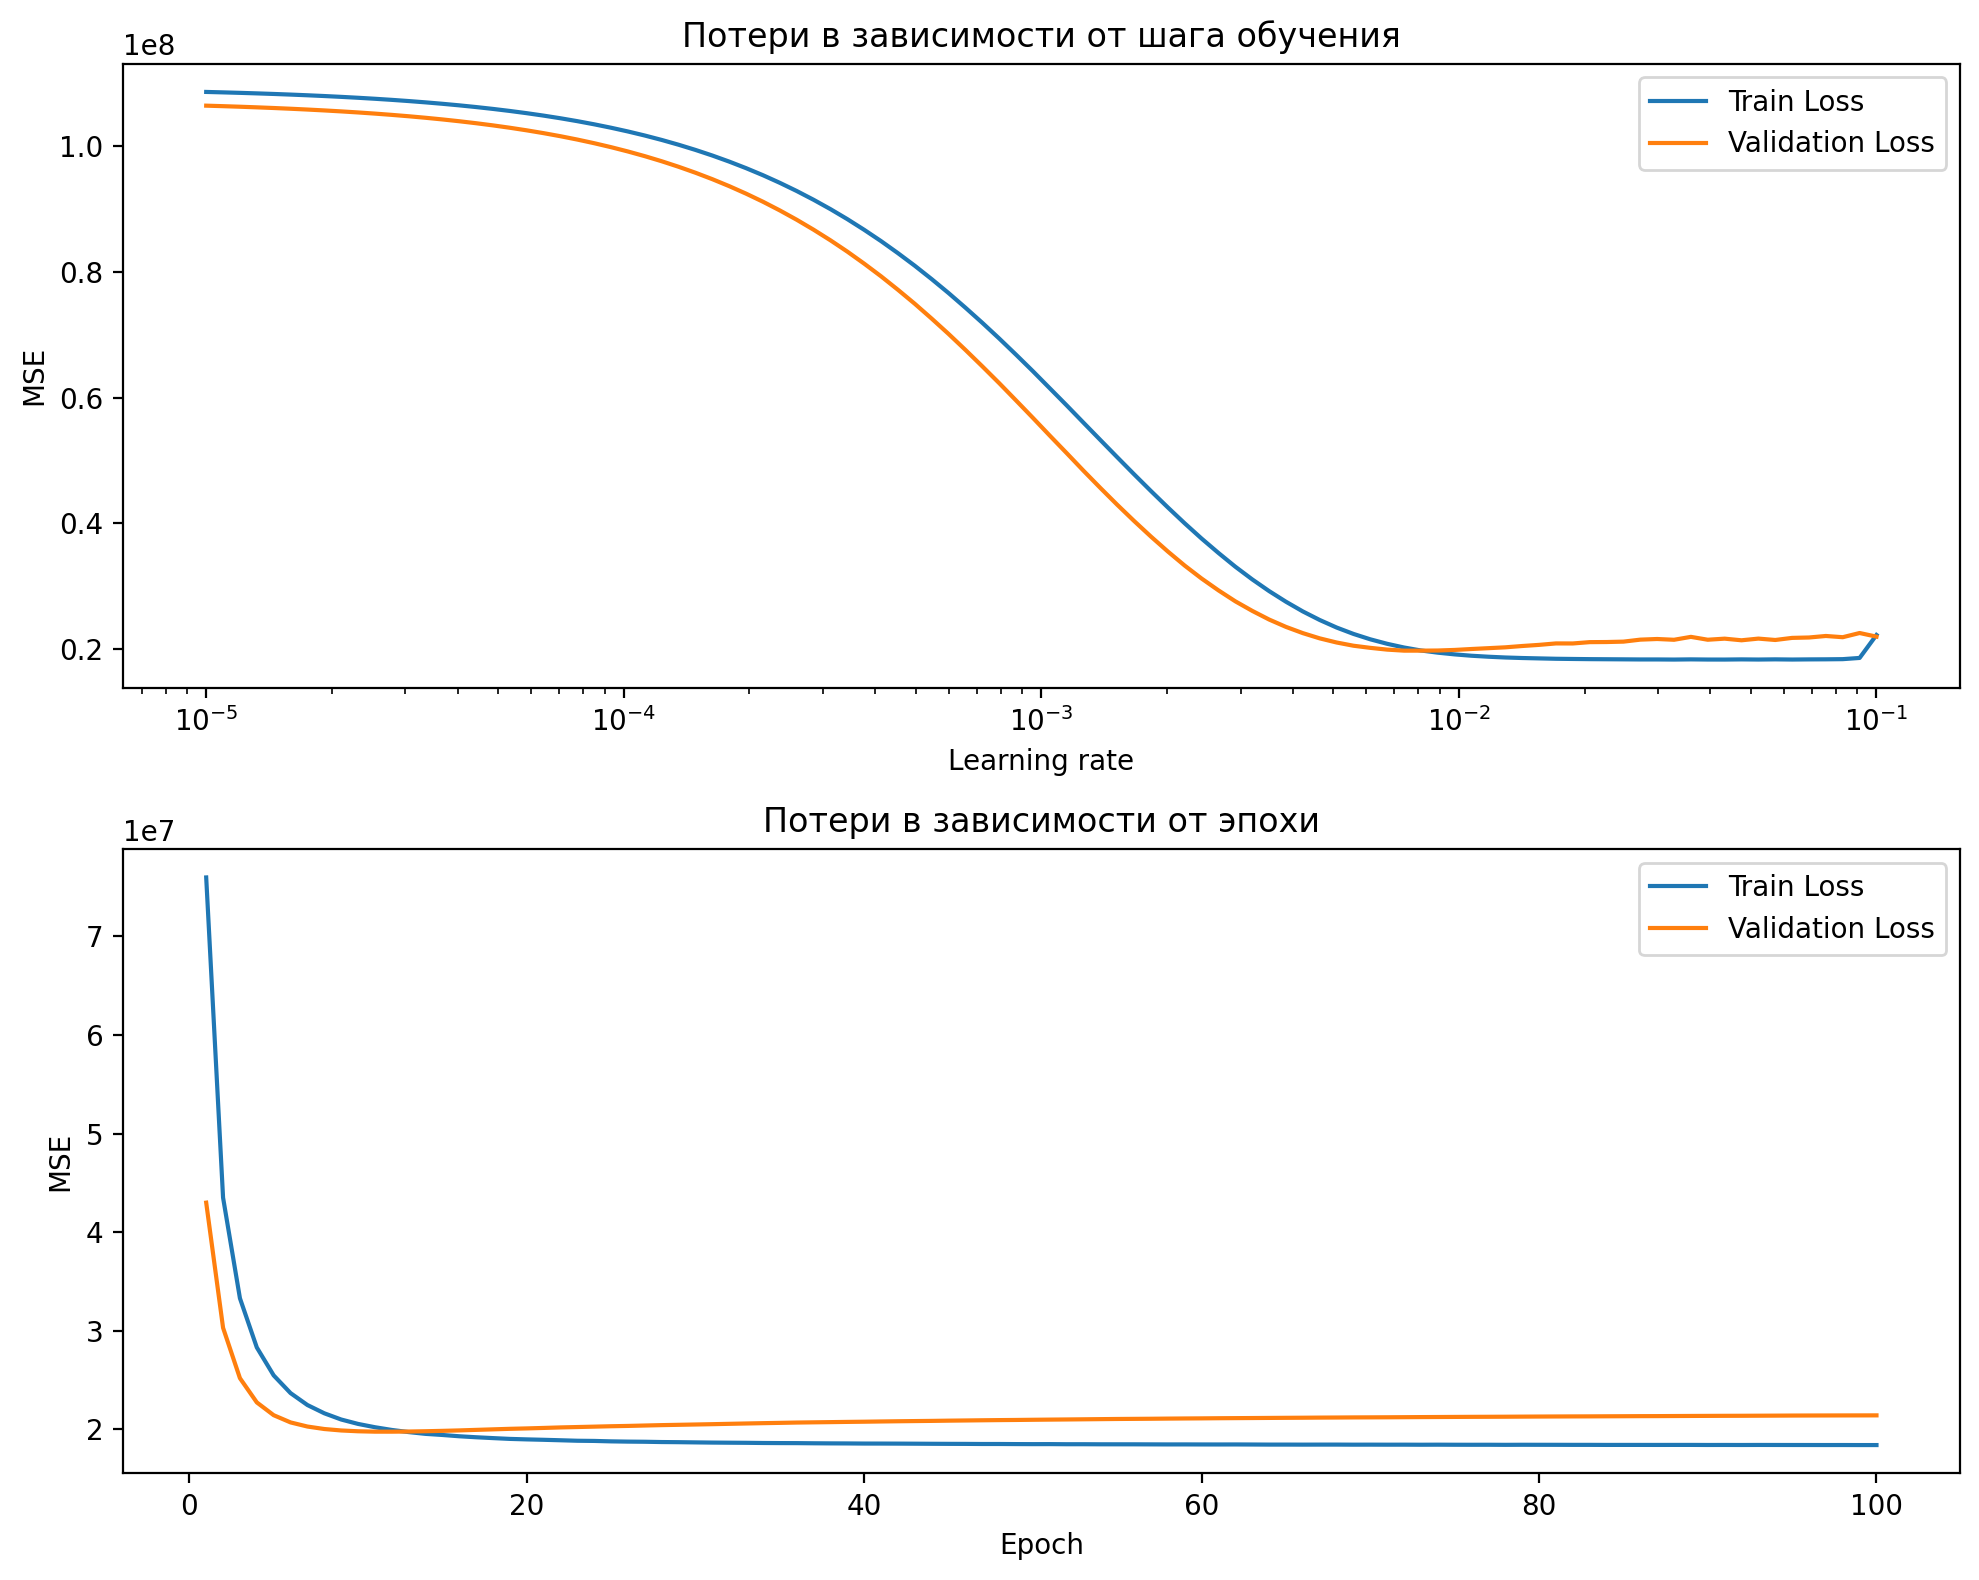

Лучший шаг: 0.007390722033525783
R2 на тестовой выборке: 0.6136
Loss на тестовой выборке: 26949184.4215
Оптимальное количество эпох: 15


In [77]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -1, 100)


class SGDLinearRegressionTimeLr:
    def __init__(self, features, learning_rate=0.01, epochs=100, batch_size=32, s=1, p=0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.s = s
        self.p = p
        self.weights = torch.zeros(
            features, 1,
            requires_grad=True,
            dtype=torch.float64
        )
        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            indices = torch.randperm(num_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            lr_factor = (self.s / (self.s + epoch)) ** self.p

            for i in range(0, num_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias
                mse = torch.mean((y_pred - y_batch) ** 2)

                mse.backward()

                with torch.no_grad():
                    self.weights -= (
                        self.learning_rate
                        * lr_factor
                        * self.weights.grad
                    )

                    self.bias -= (
                        self.learning_rate
                        * lr_factor
                        * self.bias.grad
                    )

                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(mse.item())

            self.loss_history.append(np.mean(epoch_losses))

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)

                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = SGDLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=10,
        features=X_train.shape[1],
        batch_size=32,
        s=1,
        p=0.5
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]

model = SGDLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=100,
    features=X_train.shape[1],
    batch_size=32,
    s=1,
    p=0.5
)

model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].set_title("Потери в зависимости от шага обучения")
ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Потери в зависимости от эпохи")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")

print(
    f"R2 на тестовой выборке: "
    f"{r2_score(y_test, model.predict(X_test)):.4f}"
)

print(
    f"Loss на тестовой выборке: "
    f"{mean_squared_error(y_test, model.predict(X_test)):.4f}"
)

print(f"Оптимальное количество эпох: {15}")


8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

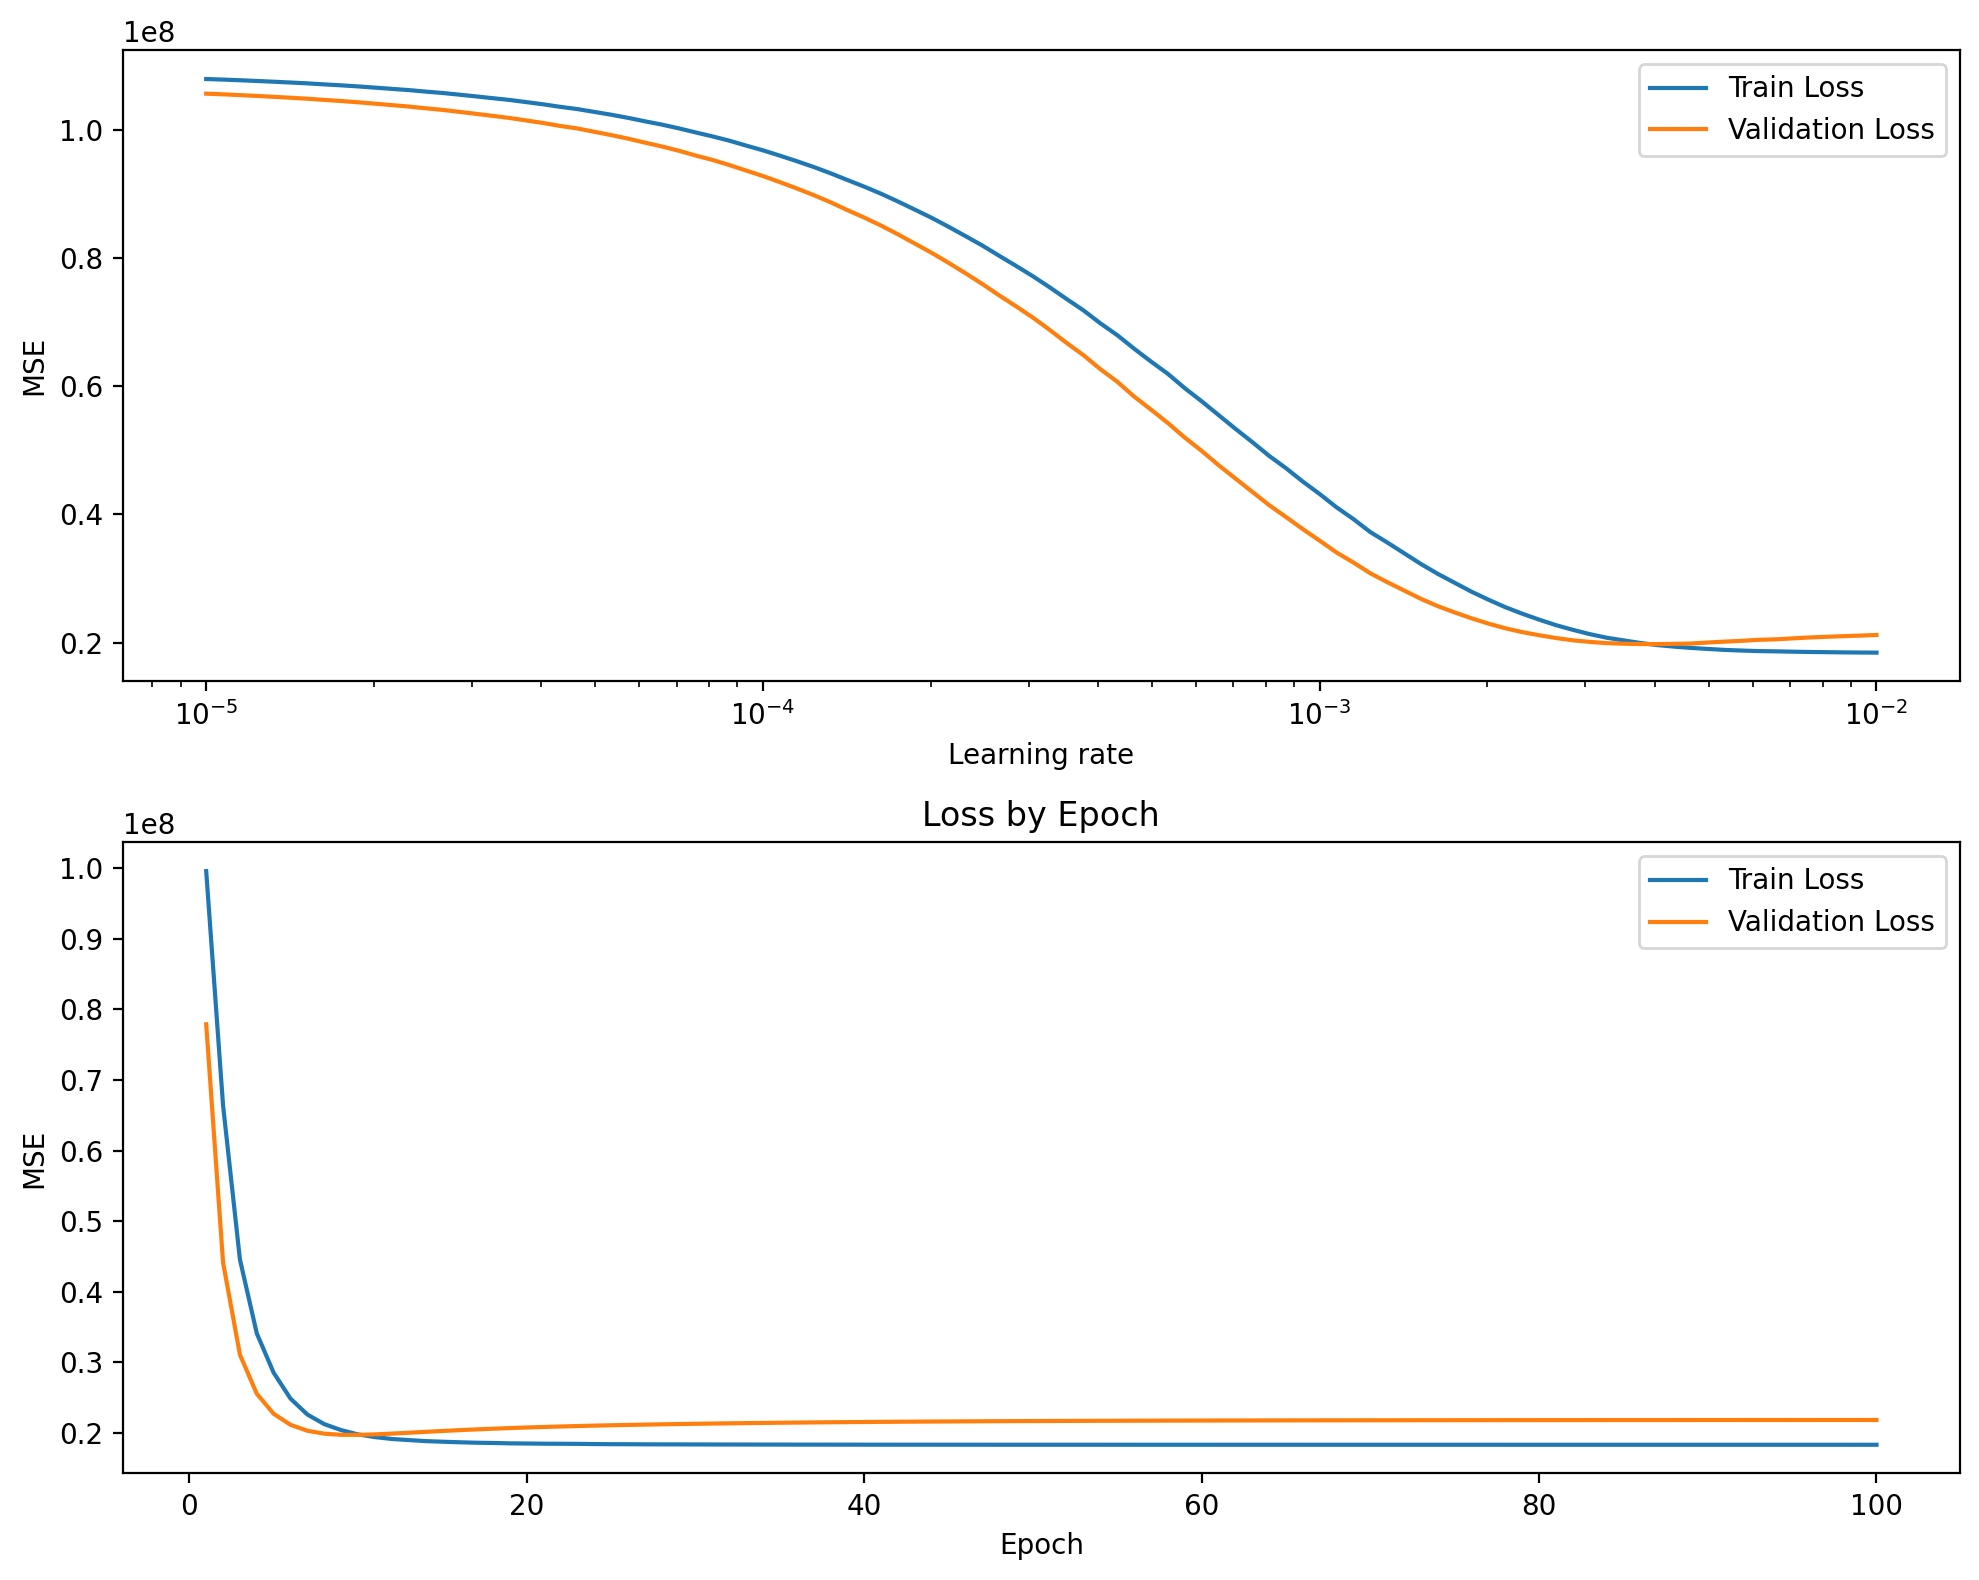

Лучший шаг: 0.004037017258596553
R2 на тестовой выборке: 0.6200
Loss на тестовой выборке: 26503220.7888
Количество эпох: 12


In [74]:
import torch
import numpy as np

class SAGLinearRegression:
    def __init__(self, features, learning_rate=0.01, epochs=100, batch_size=32):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = torch.zeros(features, 1, requires_grad=True, dtype=torch.float64)
        self.bias = torch.zeros(1, requires_grad=True, dtype=torch.float64)
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        num_samples = X.shape[0]
        self.loss_history = []
        self.val_loss_history = []

        gradient_memory_weights = torch.zeros(
            num_samples,
            X.shape[1],
            1,
            dtype=torch.float64
        )

        gradient_memory_bias = torch.zeros(
            num_samples,
            1,
            dtype=torch.float64
        )

        for epoch in range(self.epochs):
            indices = torch.randperm(num_samples)
            epoch_losses = []

            for i in range(0, num_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                with torch.no_grad():
                    y_pred = X_batch @ self.weights + self.bias

                    errors = y_pred - y_batch

                    gradients_weights = (
                        2 * errors.view(-1, 1, 1)
                        * X_batch.view(-1, X.shape[1], 1)
                    )
                    gradients_bias = 2 * errors

                    gradient_memory_weights[batch_indices] = gradients_weights
                    gradient_memory_bias[batch_indices] = gradients_bias

                    mean_gradient_weights = gradient_memory_weights.mean(dim=0)
                    mean_gradient_bias = gradient_memory_bias.mean(dim=0)

                    self.weights -= self.learning_rate * mean_gradient_weights
                    self.bias -= self.learning_rate * mean_gradient_bias

                y_pred = X_batch @ self.weights + self.bias
                mse = torch.mean((y_pred - y_batch) ** 2)

                epoch_losses.append(mse.item())

            self.loss_history.append(np.mean(epoch_losses))

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)
                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


lyamdas = np.logspace(-5, -2, 100)
losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = SAGLinearRegression(
        learning_rate=lyamda,
        epochs=10,
        features=X_train.shape[1],
        batch_size=32
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]

model = SAGLinearRegression(
    learning_rate=best_lyamda,
    epochs=100,
    features=X_train.shape[1],
    batch_size=32
)

model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Loss by Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")
print(f"R2 на тестовой выборке: {r2_score(y_test, model.predict(X_test)):.4f}")
print(f"Loss на тестовой выборке: {mean_squared_error(y_test, model.predict(X_test)):.4f}")
print(f"Количество эпох: {12}")

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

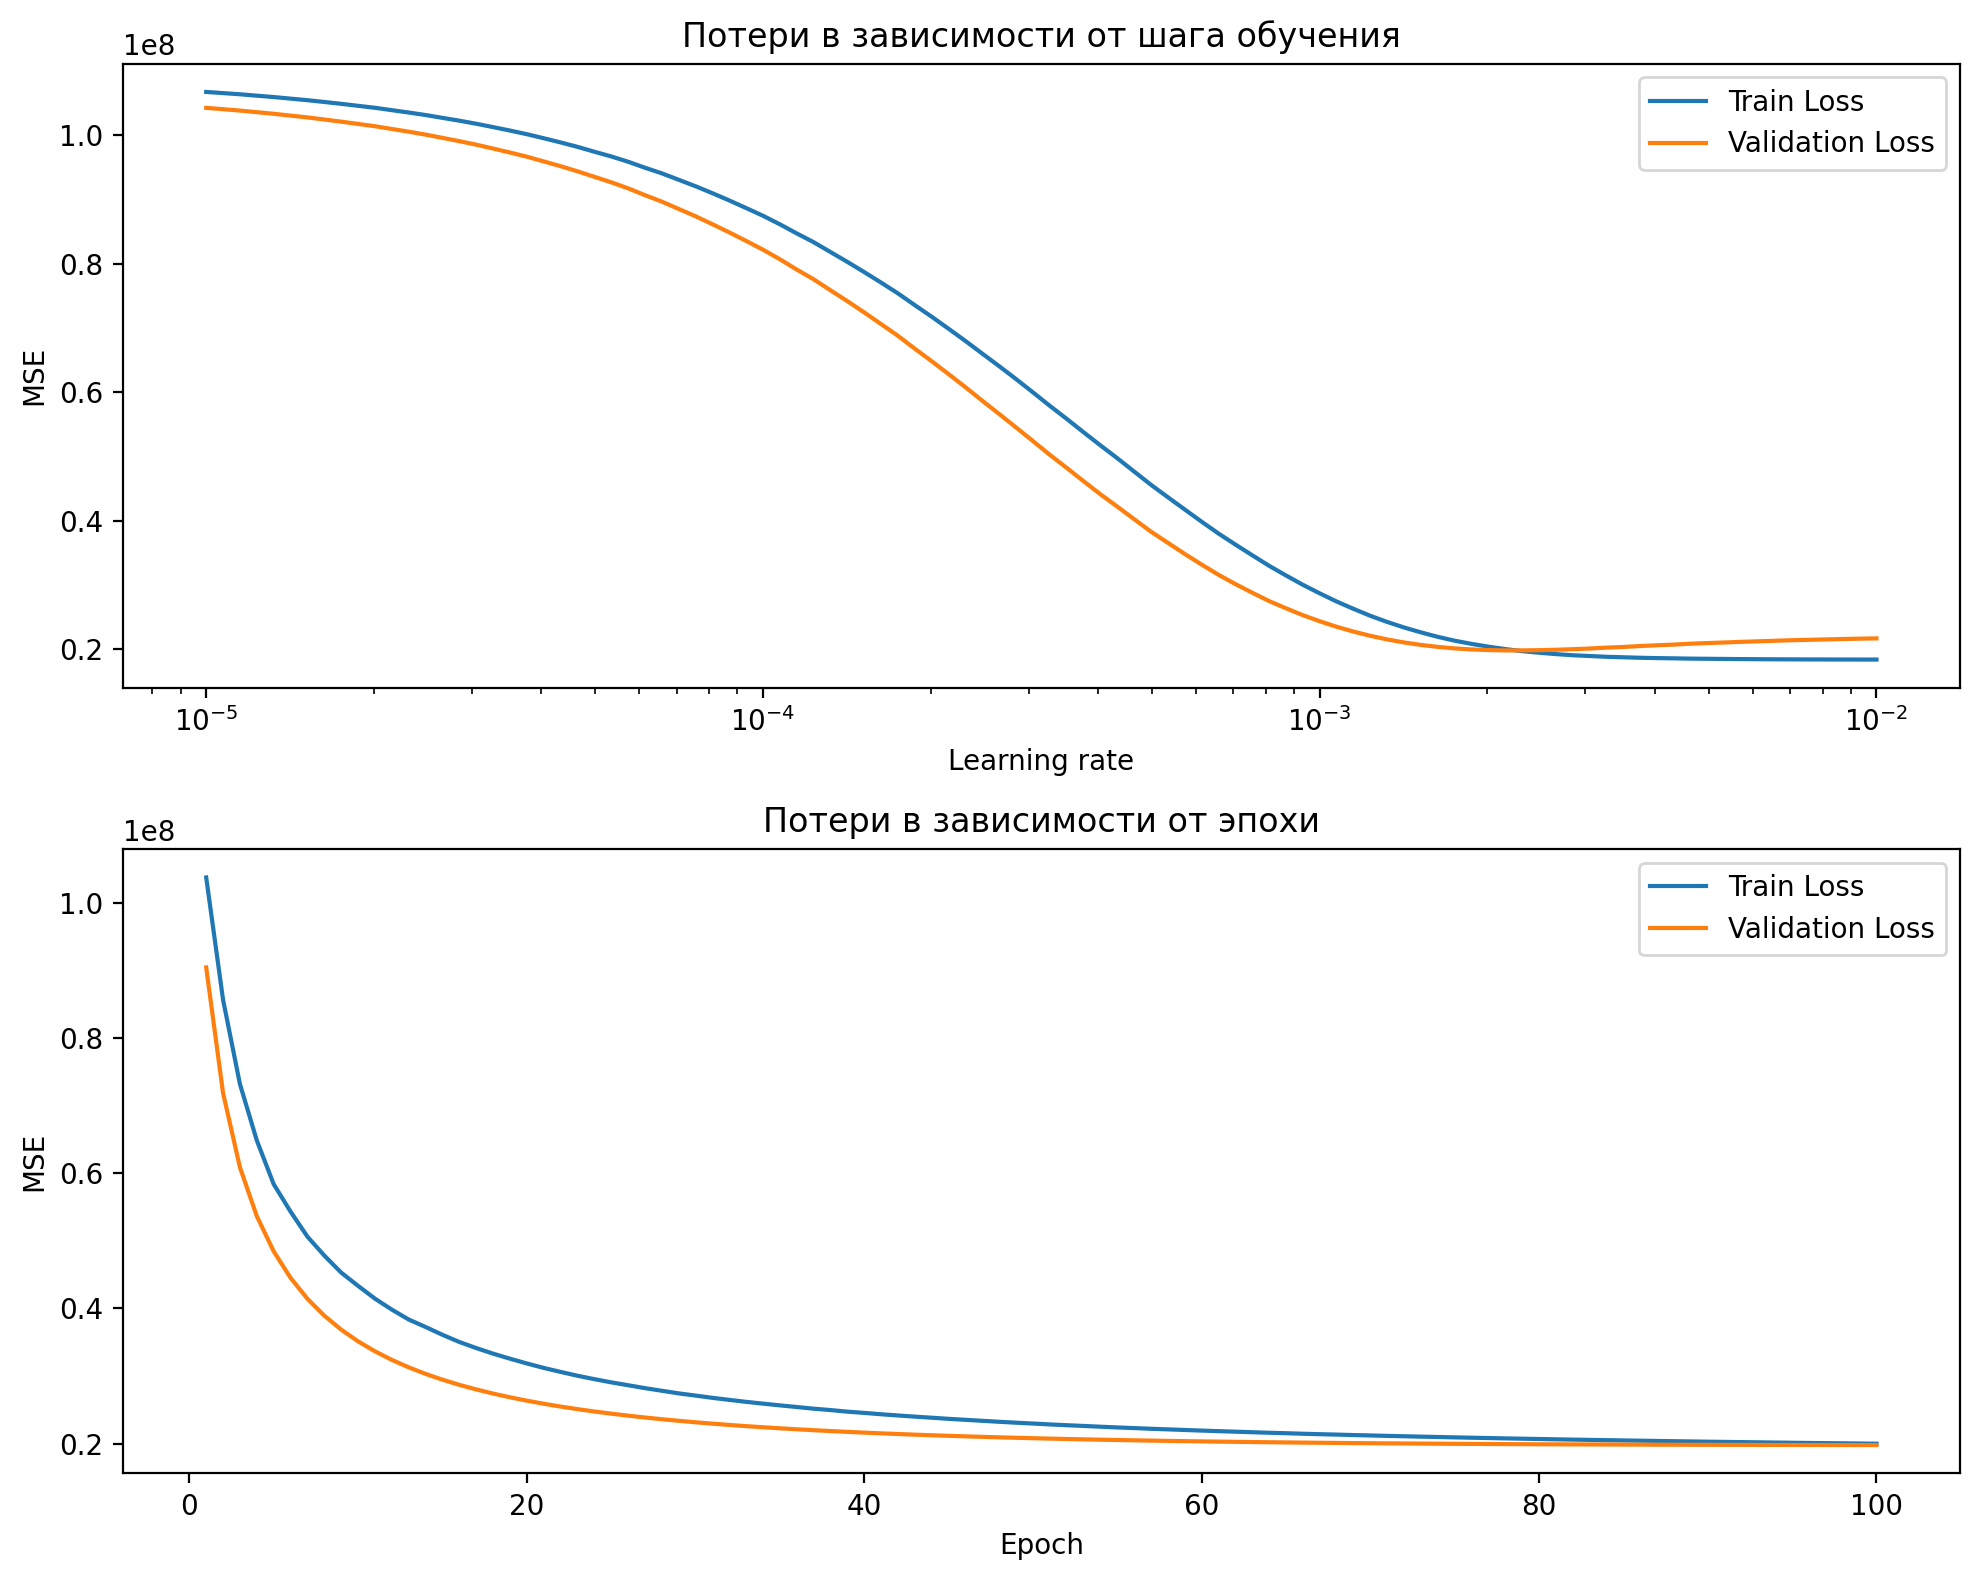

Лучший шаг: 0.0021544346900318843
Оптимальное количество эпох: 100
R2 на тестовой выборке: 0.5873
Loss на тестовой выборке: 28781400.3125


In [79]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

class SAGLinearRegressionTimeLr:
    def __init__(self, features, learning_rate=0.01, epochs=100, batch_size=32, s=1, p=0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.s = s
        self.p = p
        self.weights = torch.zeros(features, 1, requires_grad=True, dtype=torch.float64)
        self.bias = torch.zeros(1, requires_grad=True, dtype=torch.float64)
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(np.asarray(X), dtype=torch.float64)
        y = torch.tensor(np.asarray(y), dtype=torch.float64).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(np.asarray(X_val), dtype=torch.float64)
            y_val = torch.tensor(np.asarray(y_val), dtype=torch.float64).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []

        gradient_memory_weights = torch.zeros(
            num_samples,
            X.shape[1],
            1,
            dtype=torch.float64
        )

        gradient_memory_bias = torch.zeros(
            num_samples,
            1,
            dtype=torch.float64
        )

        for epoch in range(self.epochs):
            indices = torch.randperm(num_samples)
            epoch_losses = []

            lr_factor = (self.s / (self.s + epoch)) ** self.p

            for i in range(0, num_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                with torch.no_grad():
                    y_pred = X_batch @ self.weights + self.bias

                    errors = y_pred - y_batch

                    gradients_weights = (
                        2
                        * errors.view(-1, 1, 1)
                        * X_batch.view(-1, X.shape[1], 1)
                    )

                    gradients_bias = 2 * errors

                    gradient_memory_weights[batch_indices] = gradients_weights
                    gradient_memory_bias[batch_indices] = gradients_bias

                    mean_gradient_weights = gradient_memory_weights.mean(dim=0)
                    mean_gradient_bias = gradient_memory_bias.mean(dim=0)

                    self.weights -= (
                        self.learning_rate
                        * lr_factor
                        * mean_gradient_weights
                    )

                    self.bias -= (
                        self.learning_rate
                        * lr_factor
                        * mean_gradient_bias
                    )

                y_pred = X_batch @ self.weights + self.bias
                mse = torch.mean((y_pred - y_batch) ** 2)

                epoch_losses.append(mse.item())

            self.loss_history.append(np.mean(epoch_losses))

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias
                    val_mse = torch.mean((y_val_pred - y_val) ** 2)

                    self.val_loss_history.append(val_mse.item())

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(np.asarray(X), dtype=torch.float64)
            return (X @ self.weights + self.bias).detach().numpy()


lyamdas = np.logspace(-5, -2, 100)

losses_train = []
losses_val = []
r2_train = []

epochs_range = range(10, 101, 10)
epochs_losses_val = []

for epochs in epochs_range:
    model = SAGLinearRegressionTimeLr(
        learning_rate=0.001,
        epochs=epochs,
        features=X_train.shape[1],
        batch_size=32,
        s=1,
        p=0.5
    )

    model.fit(X_train, y_train, X_val, y_val)

    loss_val = model.val_loss_history[-1]

    epochs_losses_val.append(loss_val)


best_epochs = list(epochs_range)[np.argmin(epochs_losses_val)]


for lyamda in lyamdas:
    model = SAGLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=best_epochs,
        features=X_train.shape[1],
        batch_size=32,
        s=1,
        p=0.5
    )

    model.fit(X_train, y_train, X_val, y_val)

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(y_train, y_train_pred)
    r2 = r2_score(y_train, y_train_pred)

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(y_val, y_val_pred)

    losses_val.append(loss_val)


best_lyamda = lyamdas[np.argmin(losses_val)]


model = SAGLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=best_epochs,
    features=X_train.shape[1],
    batch_size=32,
    s=1,
    p=0.5
)

model.fit(X_train, y_train, X_val, y_val)


fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=200)

ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel("Learning rate")
ax[0].set_ylabel("MSE")
ax[0].set_xscale("log")
ax[0].set_title("Потери в зависимости от шага обучения")
ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_title("Потери в зависимости от эпохи")
ax[1].legend()

plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")
print(f"Оптимальное количество эпох: {best_epochs}")
print(f"R2 на тестовой выборке: {r2_score(y_test, model.predict(X_test)):.4f}")
print(f"Loss на тестовой выборке: {mean_squared_error(y_test, model.predict(X_test)):.4f}")



10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

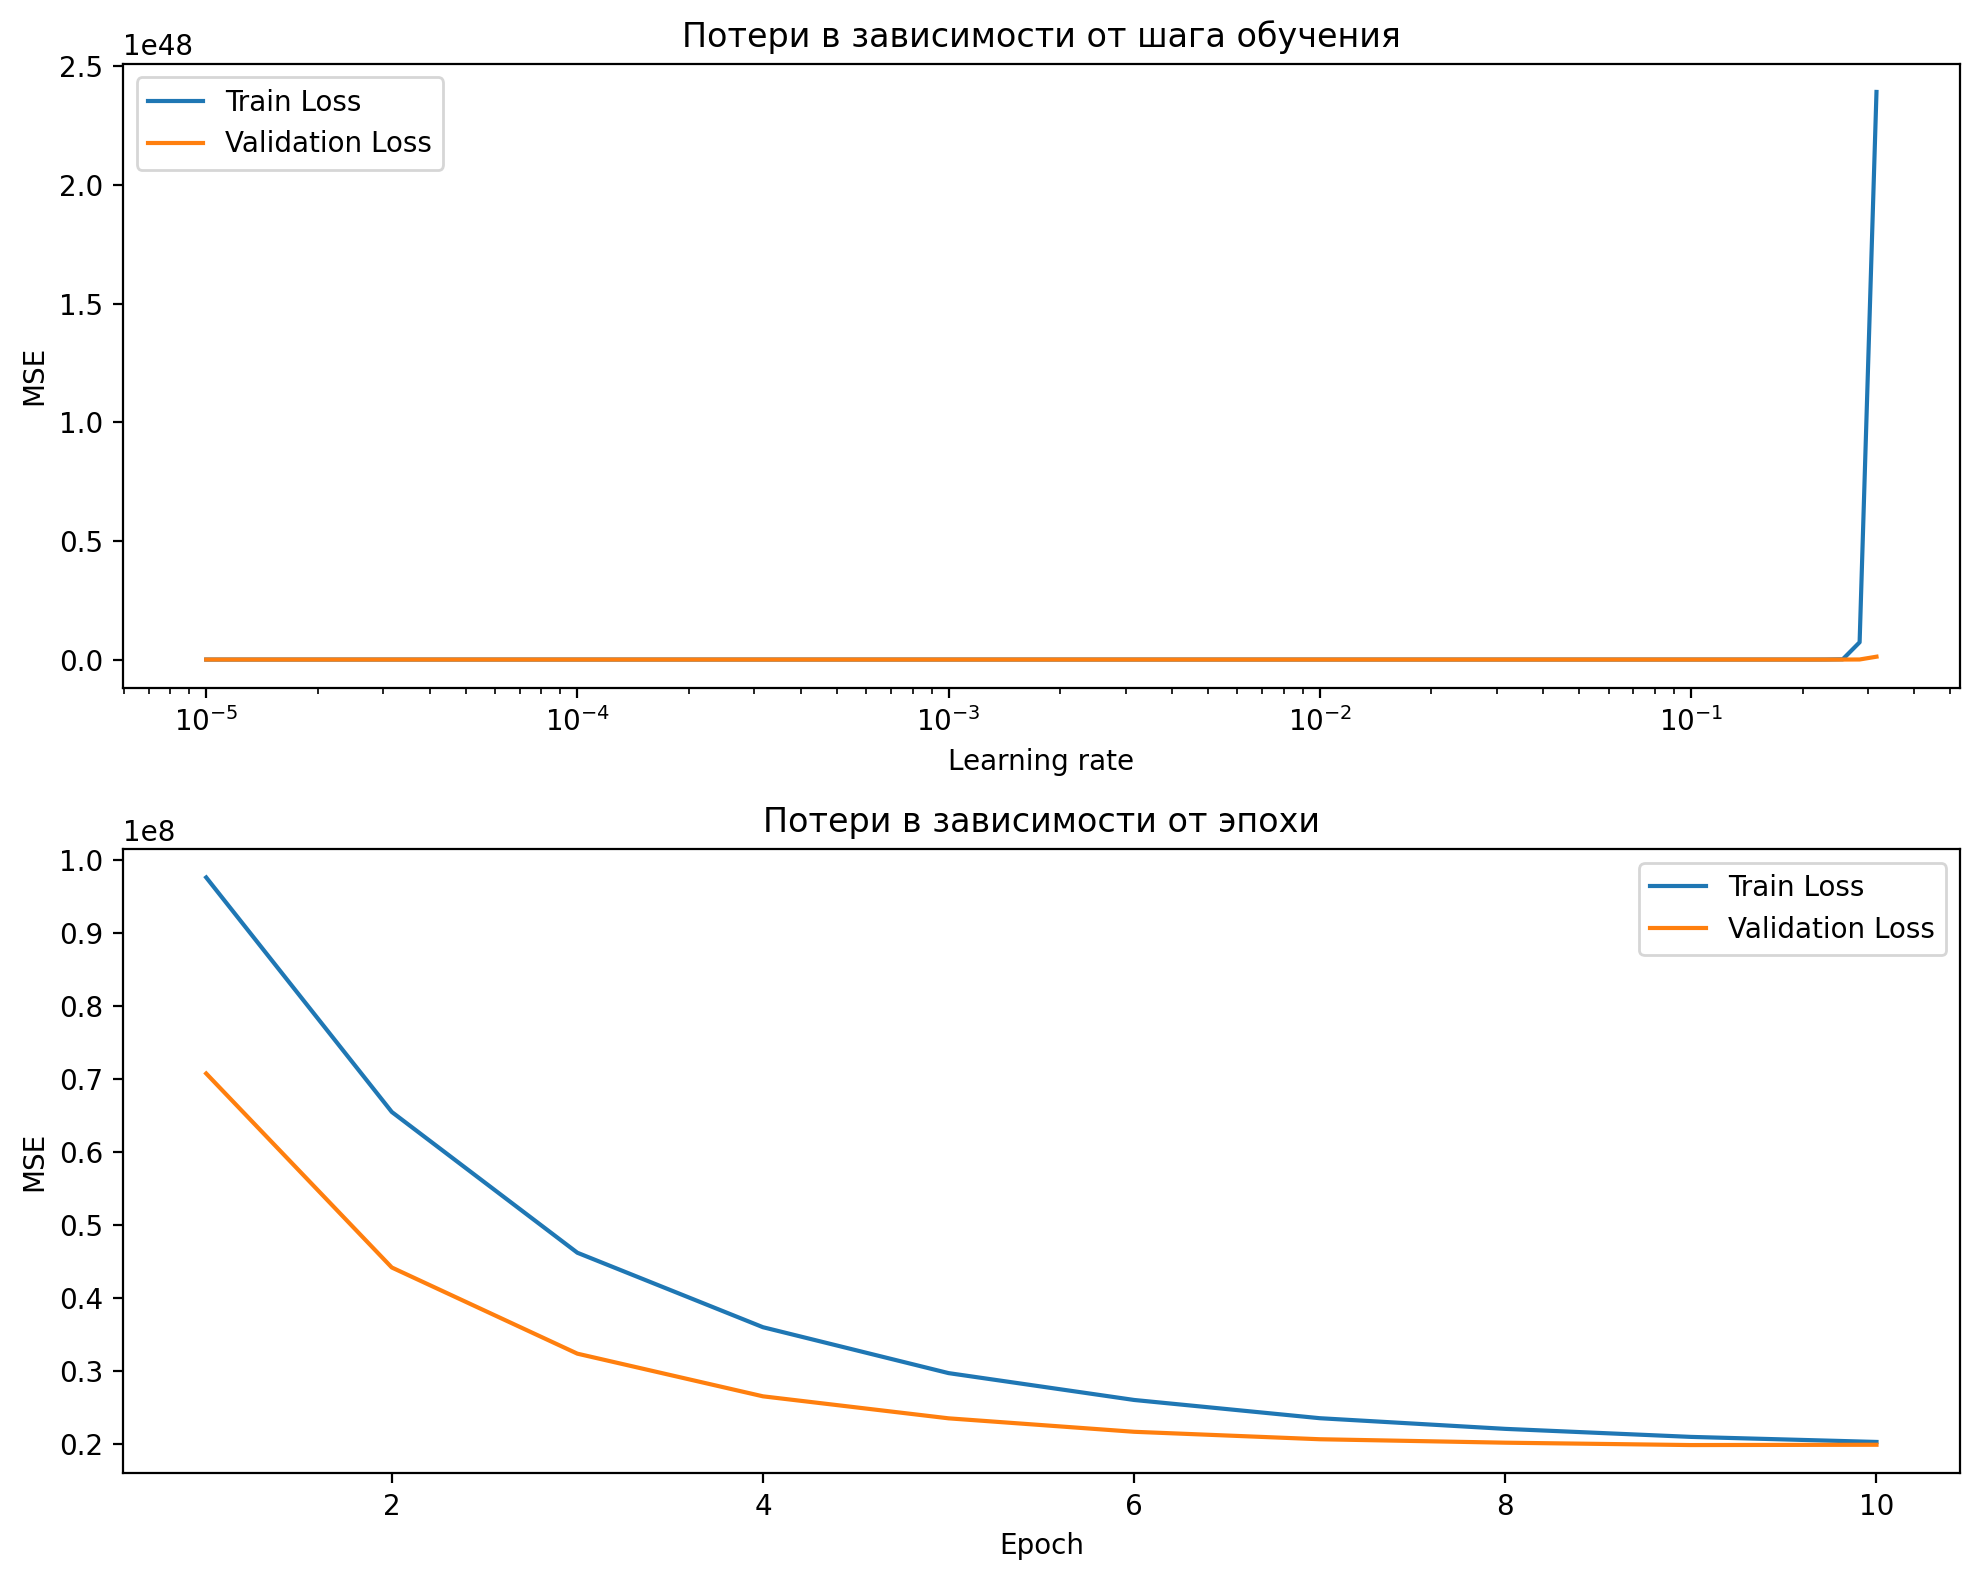

Лучший шаг: 0.0003898603702549072
Оптимальное количество эпох: 10
R2 на тестовой выборке: 0.5886
Loss на тестовой выборке: 28692580.8991


In [80]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -0.5, 100)


class MomentumLinearRegression:
    def __init__(
        self,
        features,
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        momentum=0.9
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.momentum = momentum

        self.weights = torch.zeros(
            features,
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.velocity_weights = torch.zeros(
            features,
            1,
            dtype=torch.float64
        )

        self.velocity_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(
            np.asarray(X),
            dtype=torch.float64
        )

        y = torch.tensor(
            np.asarray(y),
            dtype=torch.float64
        ).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(
                np.asarray(X_val),
                dtype=torch.float64
            )

            y_val = torch.tensor(
                np.asarray(y_val),
                dtype=torch.float64
            ).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []

        self.velocity_weights.zero_()
        self.velocity_bias.zero_()

        for epoch in range(self.epochs):
            indices = torch.randperm(num_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for i in range(0, num_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias

                mse = torch.mean(
                    (y_pred - y_batch) ** 2
                )

                mse.backward()

                with torch.no_grad():
                    self.velocity_weights = (
                        self.momentum * self.velocity_weights
                        + self.weights.grad
                    )

                    self.velocity_bias = (
                        self.momentum * self.velocity_bias
                        + self.bias.grad
                    )

                    self.weights -= (
                        self.learning_rate
                        * self.velocity_weights
                    )

                    self.bias -= (
                        self.learning_rate
                        * self.velocity_bias
                    )

                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(mse.item())

            self.loss_history.append(
                np.mean(epoch_losses)
            )

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias

                    val_mse = torch.mean(
                        (y_val_pred - y_val) ** 2
                    )

                    self.val_loss_history.append(
                        val_mse.item()
                    )

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(
                np.asarray(X),
                dtype=torch.float64
            )

            return (
                X @ self.weights + self.bias
            ).detach().numpy()


losses_train = []
losses_val = []
r2_train = []

epochs_range = range(10, 101, 10)
epochs_losses_val = []

for epochs in epochs_range:
    model = MomentumLinearRegression(
        learning_rate=0.001,
        epochs=epochs,
        features=X_train.shape[1],
        batch_size=32,
        momentum=0.9
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    loss_val = model.val_loss_history[-1]

    epochs_losses_val.append(loss_val)


best_epochs = list(epochs_range)[
    np.argmin(epochs_losses_val)
]


for lyamda in lyamdas:
    model = MomentumLinearRegression(
        learning_rate=lyamda,
        epochs=best_epochs,
        features=X_train.shape[1],
        batch_size=32,
        momentum=0.9
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(
        y_train,
        y_train_pred
    )

    r2 = r2_score(
        y_train,
        y_train_pred
    )

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(
        y_val,
        y_val_pred
    )

    losses_val.append(loss_val)


best_lyamda = lyamdas[
    np.argmin(losses_val)
]


model = MomentumLinearRegression(
    learning_rate=best_lyamda,
    epochs=best_epochs,
    features=X_train.shape[1],
    batch_size=32,
    momentum=0.9
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val
)


fig, ax = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    dpi=200
)


ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel(
    "Learning rate"
)

ax[0].set_ylabel(
    "MSE"
)

ax[0].set_xscale(
    "log"
)

ax[0].set_title(
    "Потери в зависимости от шага обучения"
)

ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "MSE"
)

ax[1].set_title(
    "Потери в зависимости от эпохи"
)

ax[1].legend()


plt.tight_layout()
plt.show()


print(f"Лучший шаг: {best_lyamda}")
print(f"Оптимальное количество эпох: {best_epochs}")

print(
    f"R2 на тестовой выборке: "
    f"{r2_score(y_test, model.predict(X_test)):.4f}"
)

print(
    f"Loss на тестовой выборке: "
    f"{mean_squared_error(y_test, model.predict(X_test)):.4f}"
)


11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

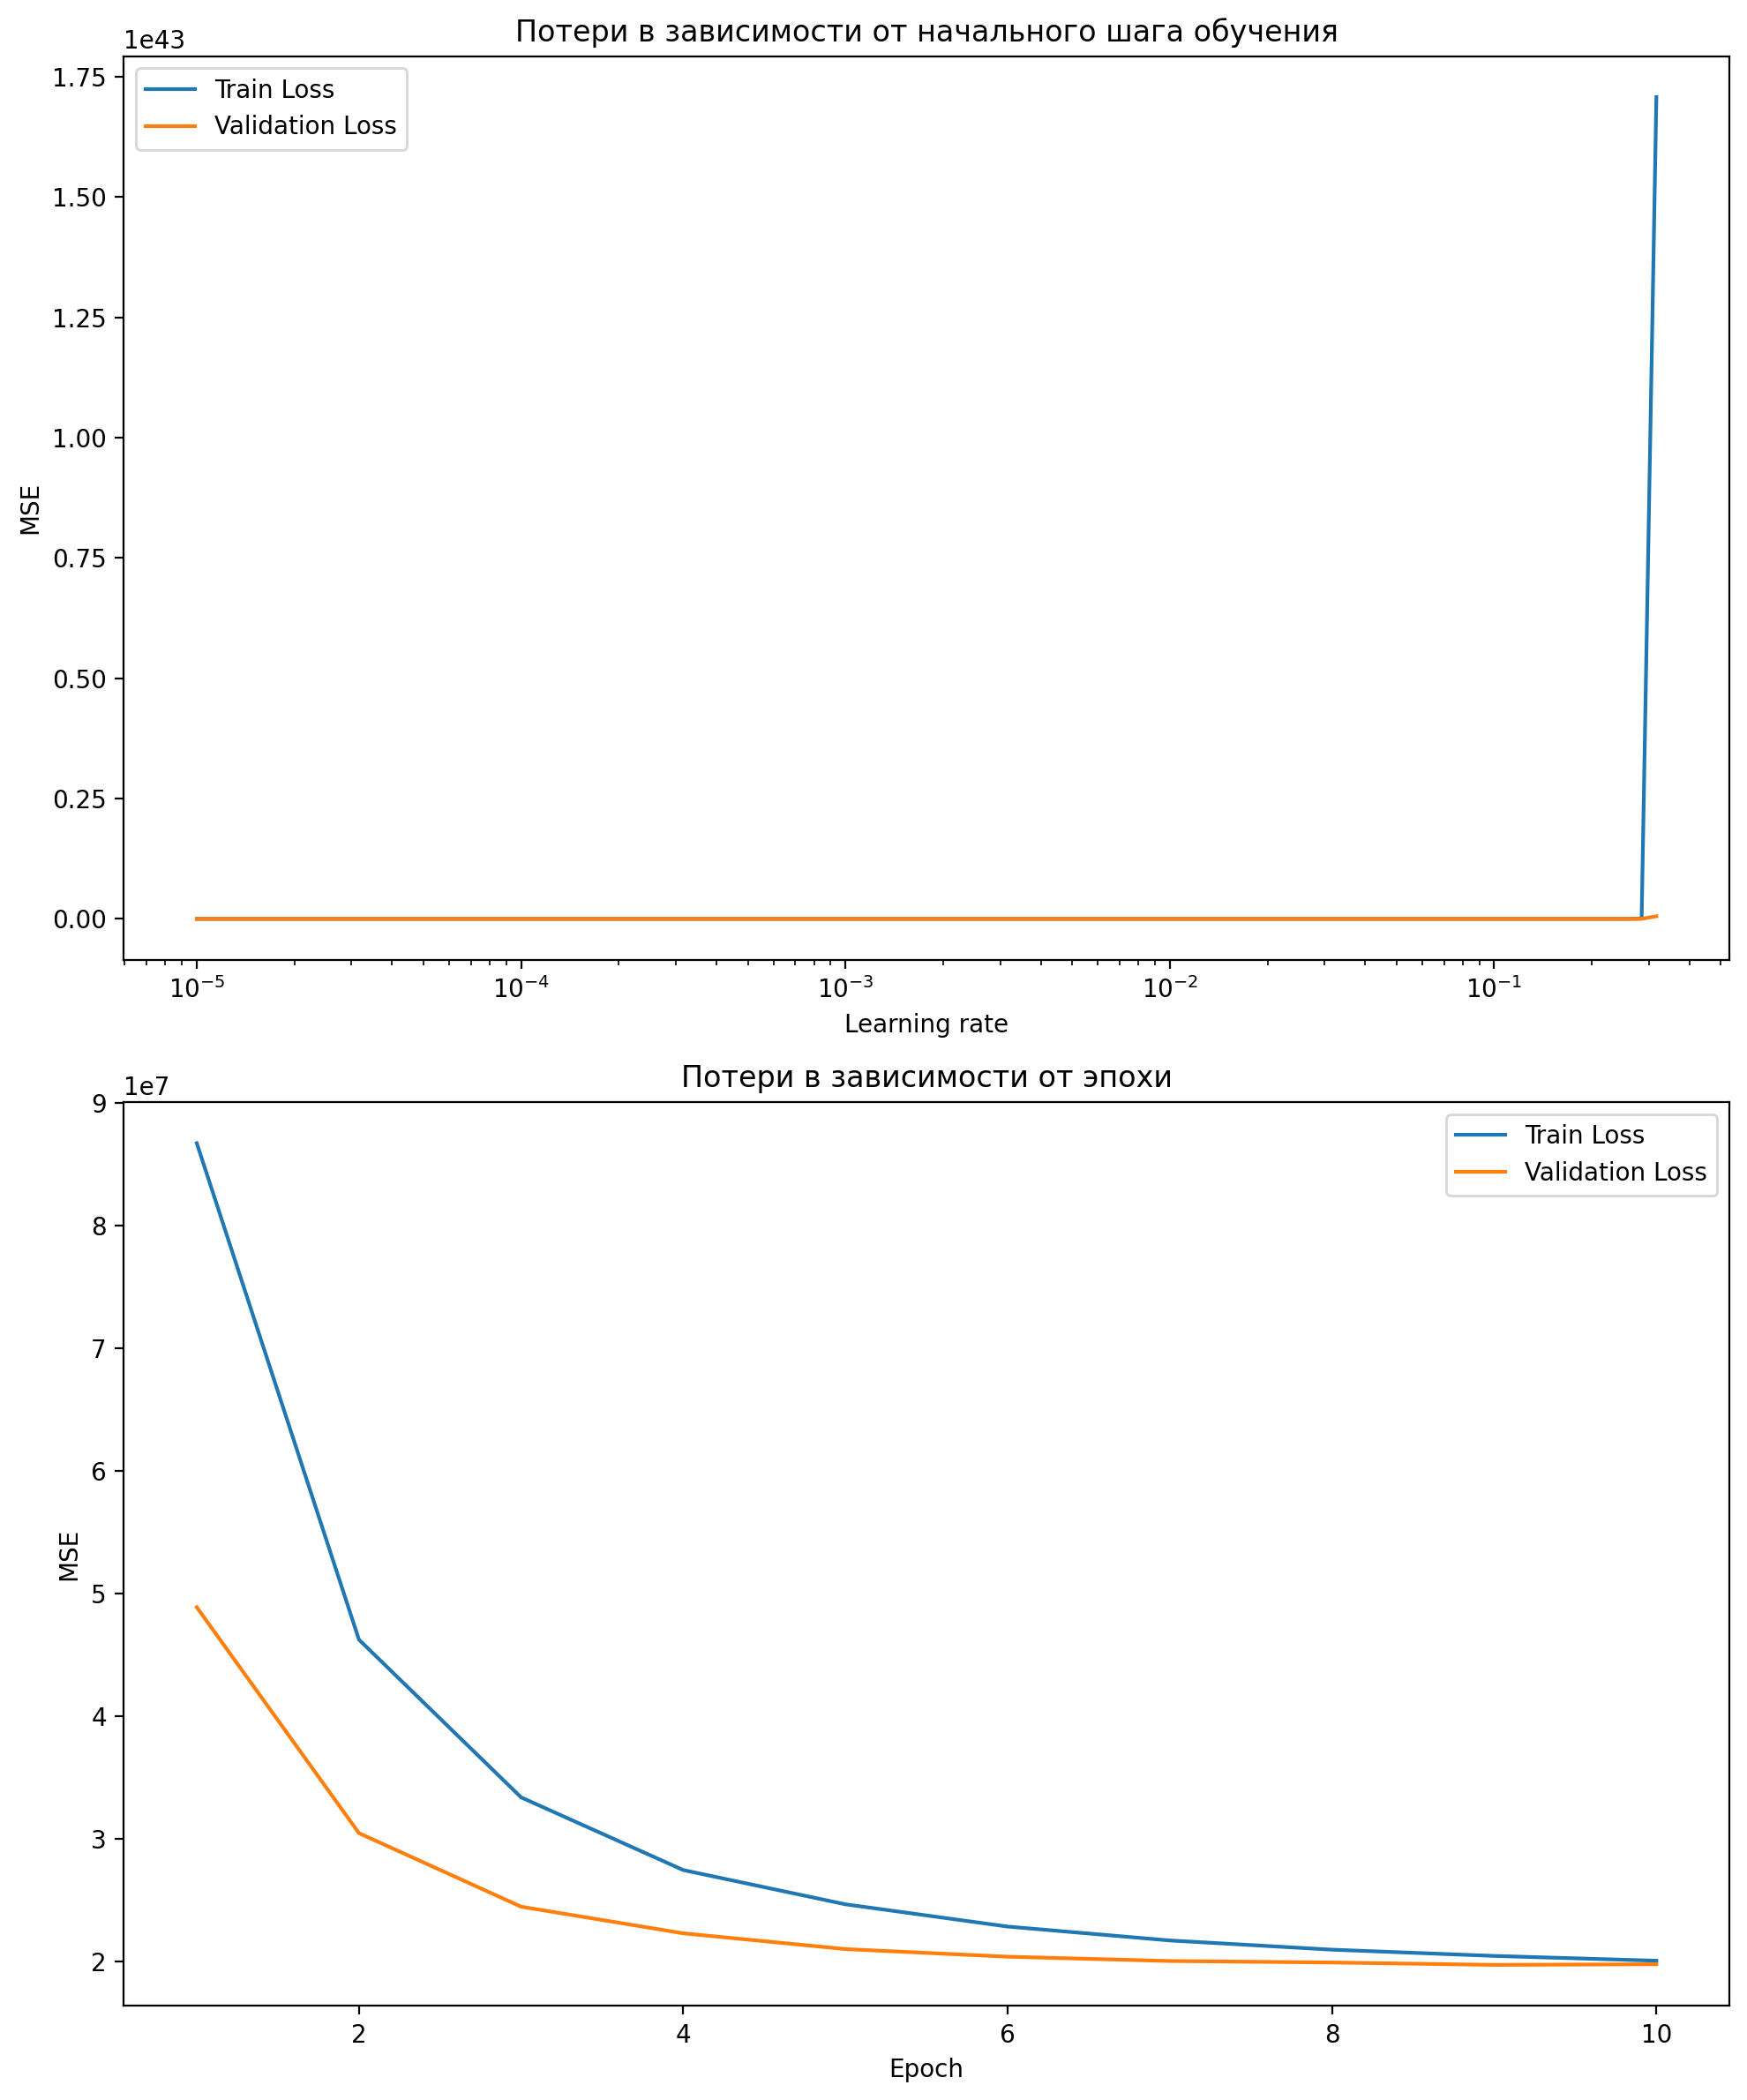

Лучший начальный шаг: 0.0008111308307896872
Оптимальное количество эпох: 10
R2 на тестовой выборке: 0.5871
Loss на тестовой выборке: 28797327.5428


In [ ]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -0.5, 100)


class MomentumLinearRegressionTimeLr:
    def __init__(
        self,
        features,
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        momentum=0.9,
        s=1,
        p=0.5
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.momentum = momentum
        self.s = s
        self.p = p

        self.weights = torch.zeros(
            features,
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.velocity_weights = torch.zeros(
            features,
            1,
            dtype=torch.float64
        )

        self.velocity_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(
            np.asarray(X),
            dtype=torch.float64
        )

        y = torch.tensor(
            np.asarray(y),
            dtype=torch.float64
        ).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(
                np.asarray(X_val),
                dtype=torch.float64
            )

            y_val = torch.tensor(
                np.asarray(y_val),
                dtype=torch.float64
            ).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

        self.velocity_weights.zero_()
        self.velocity_bias.zero_()

        for epoch in range(self.epochs):
            lr = self.learning_rate * (
                self.s / (self.s + epoch)
            ) ** self.p

            self.lr_history.append(lr)

            indices = torch.randperm(num_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for i in range(0, num_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias

                mse = torch.mean(
                    (y_pred - y_batch) ** 2
                )

                mse.backward()

                with torch.no_grad():
                    self.velocity_weights = (
                        self.momentum * self.velocity_weights
                        + self.weights.grad
                    )

                    self.velocity_bias = (
                        self.momentum * self.velocity_bias
                        + self.bias.grad
                    )

                    self.weights -= (
                        lr * self.velocity_weights
                    )

                    self.bias -= (
                        lr * self.velocity_bias
                    )

                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(mse.item())

            self.loss_history.append(
                np.mean(epoch_losses)
            )

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias

                    val_mse = torch.mean(
                        (y_val_pred - y_val) ** 2
                    )

                    self.val_loss_history.append(
                        val_mse.item()
                    )

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(
                np.asarray(X),
                dtype=torch.float64
            )

            return (
                X @ self.weights + self.bias
            ).detach().numpy()


epochs_range = range(10, 101, 10)
epochs_losses_val = []

for epochs in epochs_range:
    model = MomentumLinearRegressionTimeLr(
        learning_rate=0.001,
        epochs=epochs,
        features=X_train.shape[1],
        batch_size=32,
        momentum=0.9,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    epochs_losses_val.append(
        model.val_loss_history[-1]
    )


best_epochs = list(epochs_range)[
    np.argmin(epochs_losses_val)
]


losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = MomentumLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=best_epochs,
        features=X_train.shape[1],
        batch_size=32,
        momentum=0.9,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(
        y_train,
        y_train_pred
    )

    r2 = r2_score(
        y_train,
        y_train_pred
    )

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(
        y_val,
        y_val_pred
    )

    losses_val.append(loss_val)


best_lyamda = lyamdas[
    np.argmin(losses_val)
]


model = MomentumLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=best_epochs,
    features=X_train.shape[1],
    batch_size=32,
    momentum=0.9,
    s=1,
    p=0.5
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val
)


fig, ax = plt.subplots(
    3,
    1,
    figsize=(10, 12),
    dpi=200
)


ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel(
    "Learning rate"
)

ax[0].set_ylabel(
    "MSE"
)

ax[0].set_xscale(
    "log"
)

ax[0].set_title(
    "Потери в зависимости от начального шага обучения"
)

ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "MSE"
)

ax[1].set_title(
    "Потери в зависимости от эпохи"
)

ax[1].legend()


ax[2].plot(
    range(1, model.epochs + 1),
    model.lr_history
)

ax[2].set_xlabel(
    "Epoch"
)

ax[2].set_ylabel(
    "Learning rate"
)

ax[2].set_title(
    "Изменение шага обучения по эпохам")


plt.tight_layout()
plt.show()


print(f"Лучший начальный шаг: {best_lyamda}")
print(f"Оптимальное количество эпох: {best_epochs}")

print(
    f"R2 на тестовой выборке: "
    f"{r2_score(y_test, model.predict(X_test)):.4f}"
)

print(
    f"Loss на тестовой выборке: "
    f"{mean_squared_error(y_test, model.predict(X_test)):.4f}"
)



12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

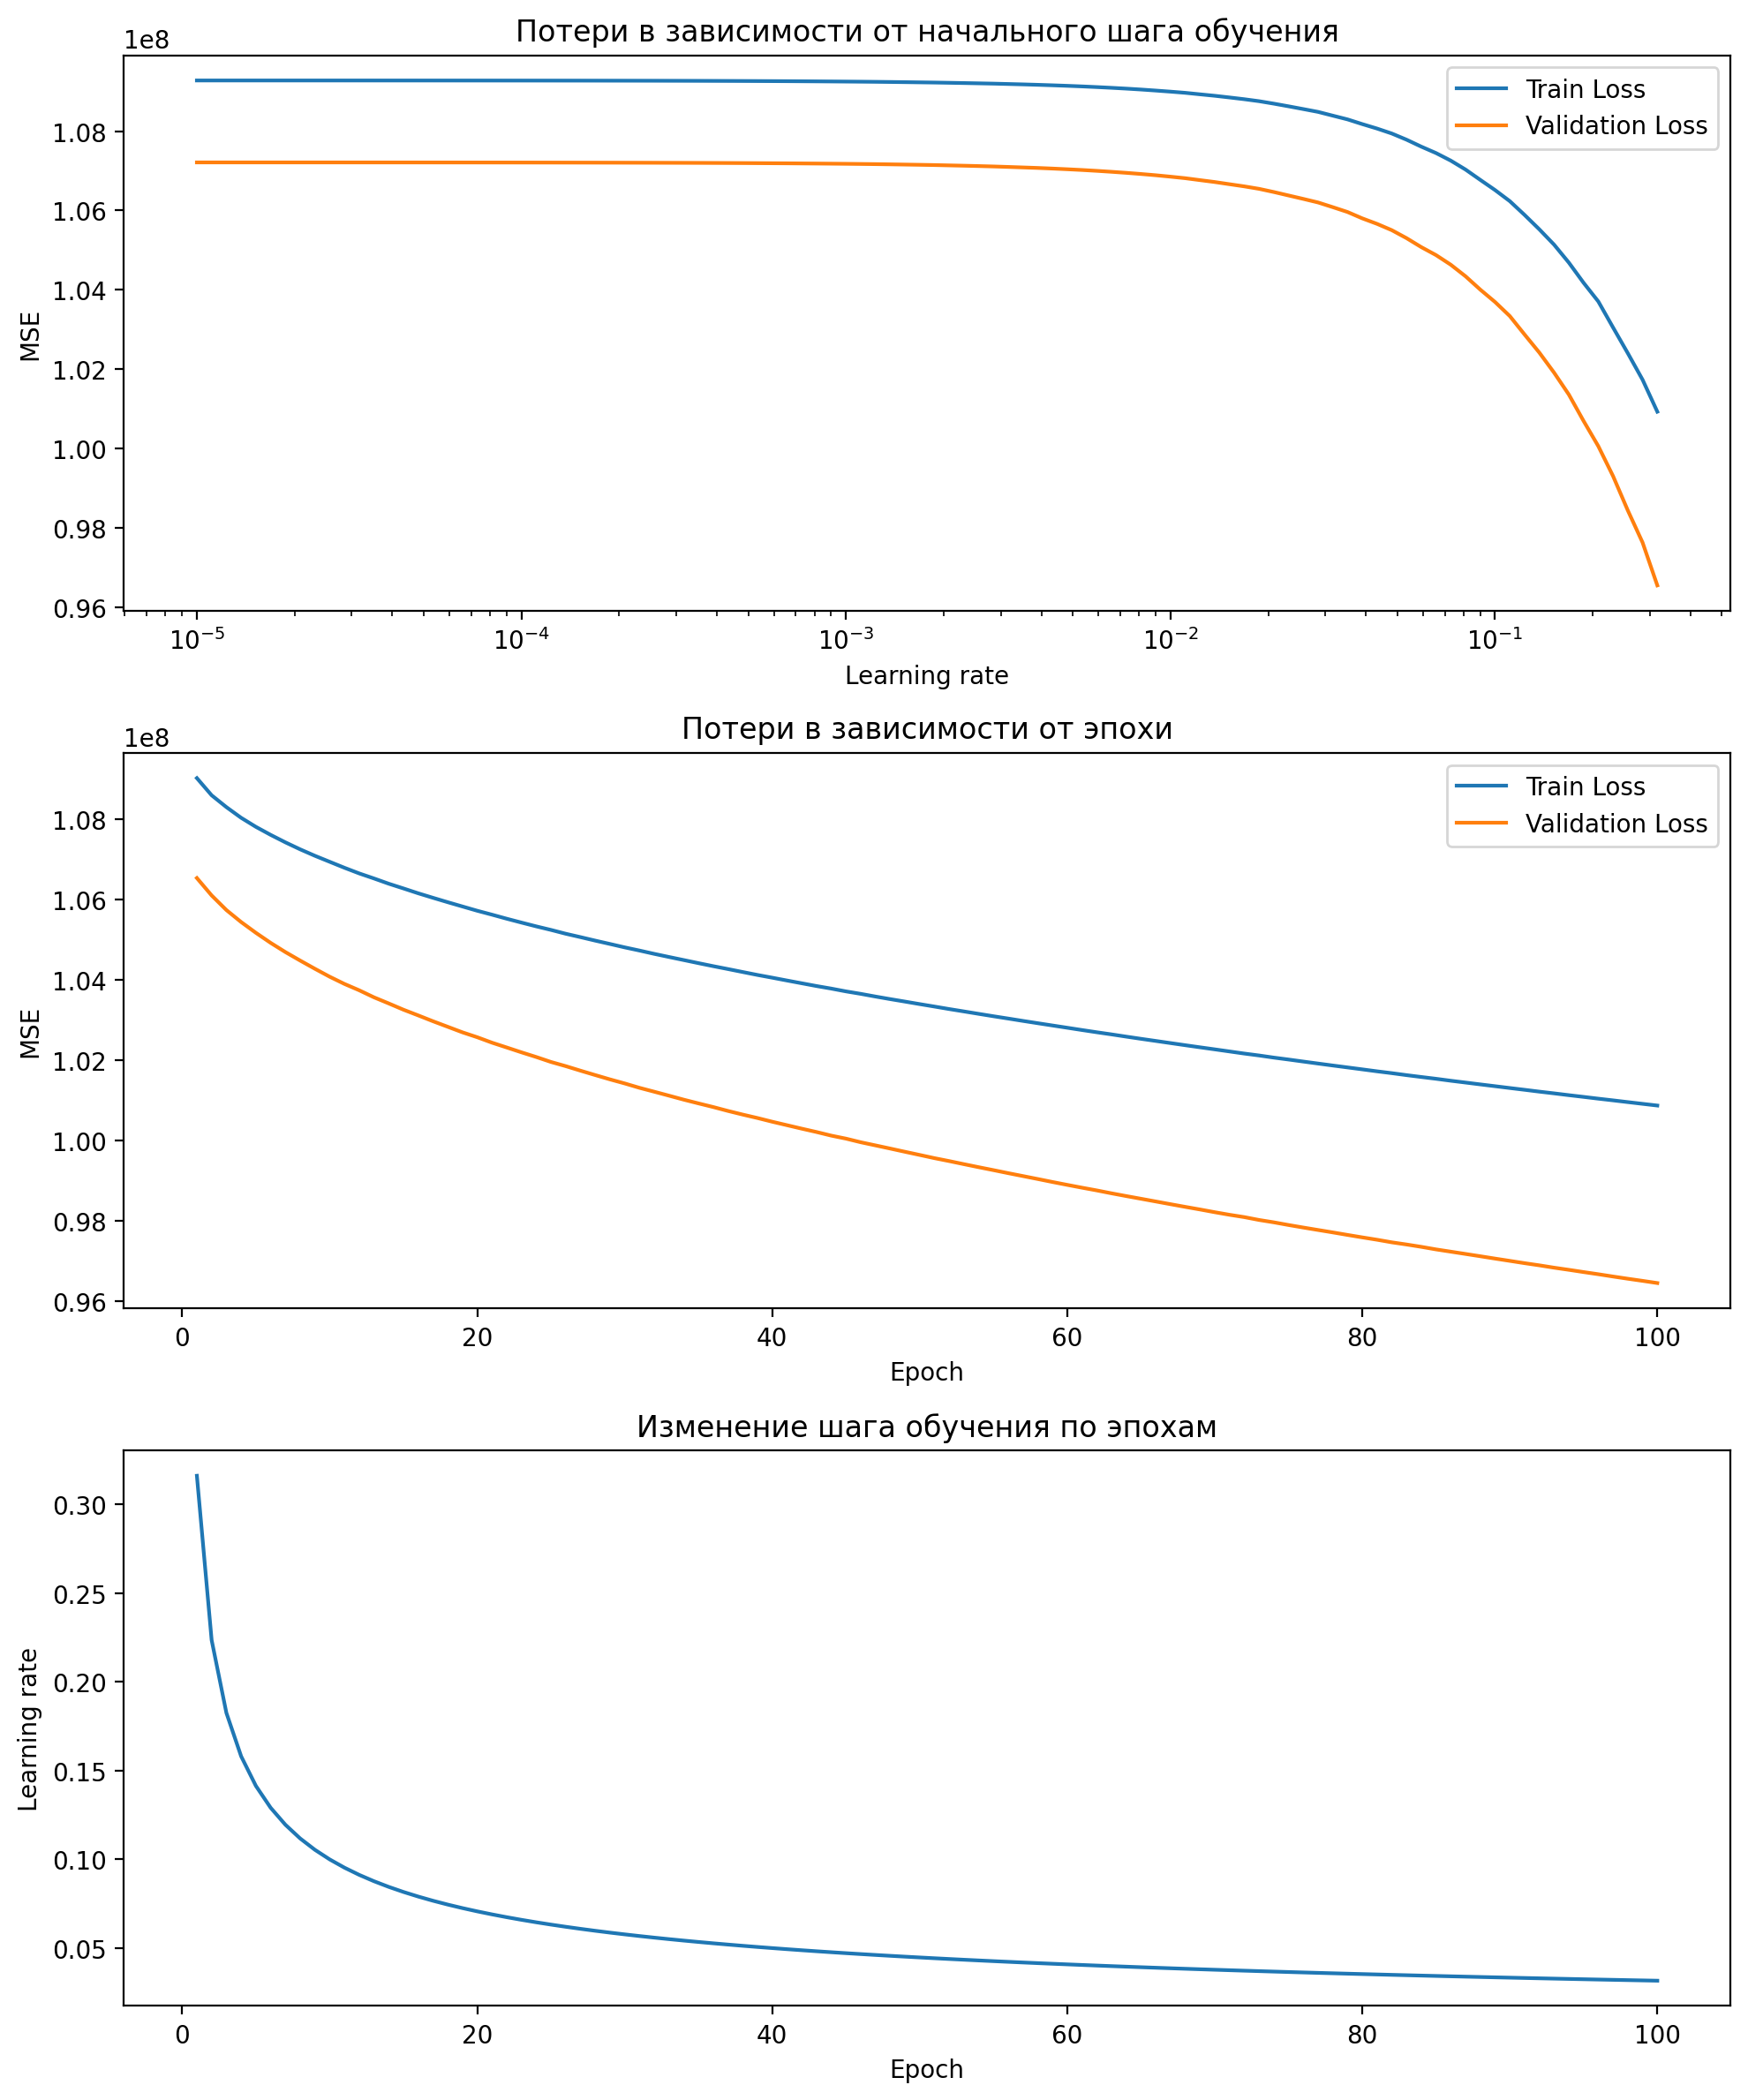

Лучший начальный шаг: 0.31622776601683794
Оптимальное количество эпох: 100
R2 на тестовой выборке: -0.7120
Loss на тестовой выборке: 119389123.8925


In [97]:

import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -0.5, 100)


class AdamLinearRegressionTimeLr:
    def __init__(
        self,
        features,
        learning_rate=0.001,
        epochs=100,
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.s = s
        self.p = p

        self.weights = torch.zeros(
            features,
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.m_weights = torch.zeros(
            features,
            1,
            dtype=torch.float64
        )

        self.m_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.v_weights = torch.zeros(
            features,
            1,
            dtype=torch.float64
        )

        self.v_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(
            np.asarray(X),
            dtype=torch.float64
        )

        y = torch.tensor(
            np.asarray(y),
            dtype=torch.float64
        ).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(
                np.asarray(X_val),
                dtype=torch.float64
            )

            y_val = torch.tensor(
                np.asarray(y_val),
                dtype=torch.float64
            ).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

        self.m_weights.zero_()
        self.m_bias.zero_()
        self.v_weights.zero_()
        self.v_bias.zero_()

        t = 0

        for epoch in range(self.epochs):
            lr = self.learning_rate * (
                self.s / (self.s + epoch)
            ) ** self.p

            self.lr_history.append(lr)

            indices = torch.randperm(num_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for i in range(0, num_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias

                mse = torch.mean(
                    (y_pred - y_batch) ** 2
                )

                mse.backward()

                t += 1

                with torch.no_grad():
                    self.m_weights = (
                        self.beta1 * self.m_weights
                        + (1 - self.beta1) * self.weights.grad
                    )

                    self.m_bias = (
                        self.beta1 * self.m_bias
                        + (1 - self.beta1) * self.bias.grad
                    )

                    self.v_weights = (
                        self.beta2 * self.v_weights
                        + (1 - self.beta2) * self.weights.grad ** 2
                    )

                    self.v_bias = (
                        self.beta2 * self.v_bias
                        + (1 - self.beta2) * self.bias.grad ** 2
                    )

                    m_weights_hat = (
                        self.m_weights
                        / (1 - self.beta1 ** t)
                    )

                    m_bias_hat = (
                        self.m_bias
                        / (1 - self.beta1 ** t)
                    )

                    v_weights_hat = (
                        self.v_weights
                        / (1 - self.beta2 ** t)
                    )

                    v_bias_hat = (
                        self.v_bias
                        / (1 - self.beta2 ** t)
                    )

                    self.weights -= (
                        lr
                        * m_weights_hat
                        / (
                            torch.sqrt(v_weights_hat)
                            + self.epsilon
                        )
                    )

                    self.bias -= (
                        lr
                        * m_bias_hat
                        / (
                            torch.sqrt(v_bias_hat)
                            + self.epsilon
                        )
                    )

                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(mse.item())

            self.loss_history.append(
                np.mean(epoch_losses)
            )

            if X_val is not None and y_val is not None:
                with torch.no_grad():
                    y_val_pred = X_val @ self.weights + self.bias

                    val_mse = torch.mean(
                        (y_val_pred - y_val) ** 2
                    )

                    self.val_loss_history.append(
                        val_mse.item()
                    )

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(
                np.asarray(X),
                dtype=torch.float64
            )

            return (
                X @ self.weights + self.bias
            ).detach().numpy()


epochs_range = range(10, 101, 10)
epochs_losses_val = []

for epochs in epochs_range:
    model = AdamLinearRegressionTimeLr(
        learning_rate=0.001,
        epochs=epochs,
        features=X_train.shape[1],
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    epochs_losses_val.append(
        model.val_loss_history[-1]
    )


best_epochs = list(epochs_range)[
    np.argmin(epochs_losses_val)
]


losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:
    model = AdamLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=best_epochs,
        features=X_train.shape[1],
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    y_train_pred = model.predict(X_train)

    loss_train = mean_squared_error(
        y_train,
        y_train_pred
    )

    r2 = r2_score(
        y_train,
        y_train_pred
    )

    losses_train.append(loss_train)
    r2_train.append(r2)

    y_val_pred = model.predict(X_val)

    loss_val = mean_squared_error(
        y_val,
        y_val_pred
    )

    losses_val.append(loss_val)


best_lyamda = lyamdas[
    np.argmin(losses_val)
]


model = AdamLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=best_epochs,
    features=X_train.shape[1],
    batch_size=32,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    s=1,
    p=0.5
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val
)


fig, ax = plt.subplots(
    3,
    1,
    figsize=(10, 12),
    dpi=200
)


ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel(
    "Learning rate"
)

ax[0].set_ylabel(
    "MSE"
)

ax[0].set_xscale(
    "log"
)

ax[0].set_title(
    "Потери в зависимости от начального шага обучения"
)

ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "MSE"
)

ax[1].set_title(
    "Потери в зависимости от эпохи"
)

ax[1].legend()


ax[2].plot(
    range(1, model.epochs + 1),
    model.lr_history
)

ax[2].set_xlabel(
    "Epoch"
)

ax[2].set_ylabel(
    "Learning rate"
)

ax[2].set_title(
    "Изменение шага обучения по эпохам"
)


plt.tight_layout()
plt.show()


print(f"Лучший начальный шаг: {best_lyamda}")
print(f"Оптимальное количество эпох: {best_epochs}")

print(
    f"R2 на тестовой выборке: "
    f"{r2_score(y_test, model.predict(X_test)):.4f}"
)

print(
    f"Loss на тестовой выборке: "
    f"{mean_squared_error(y_test, model.predict(X_test)):.4f}"
)



13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

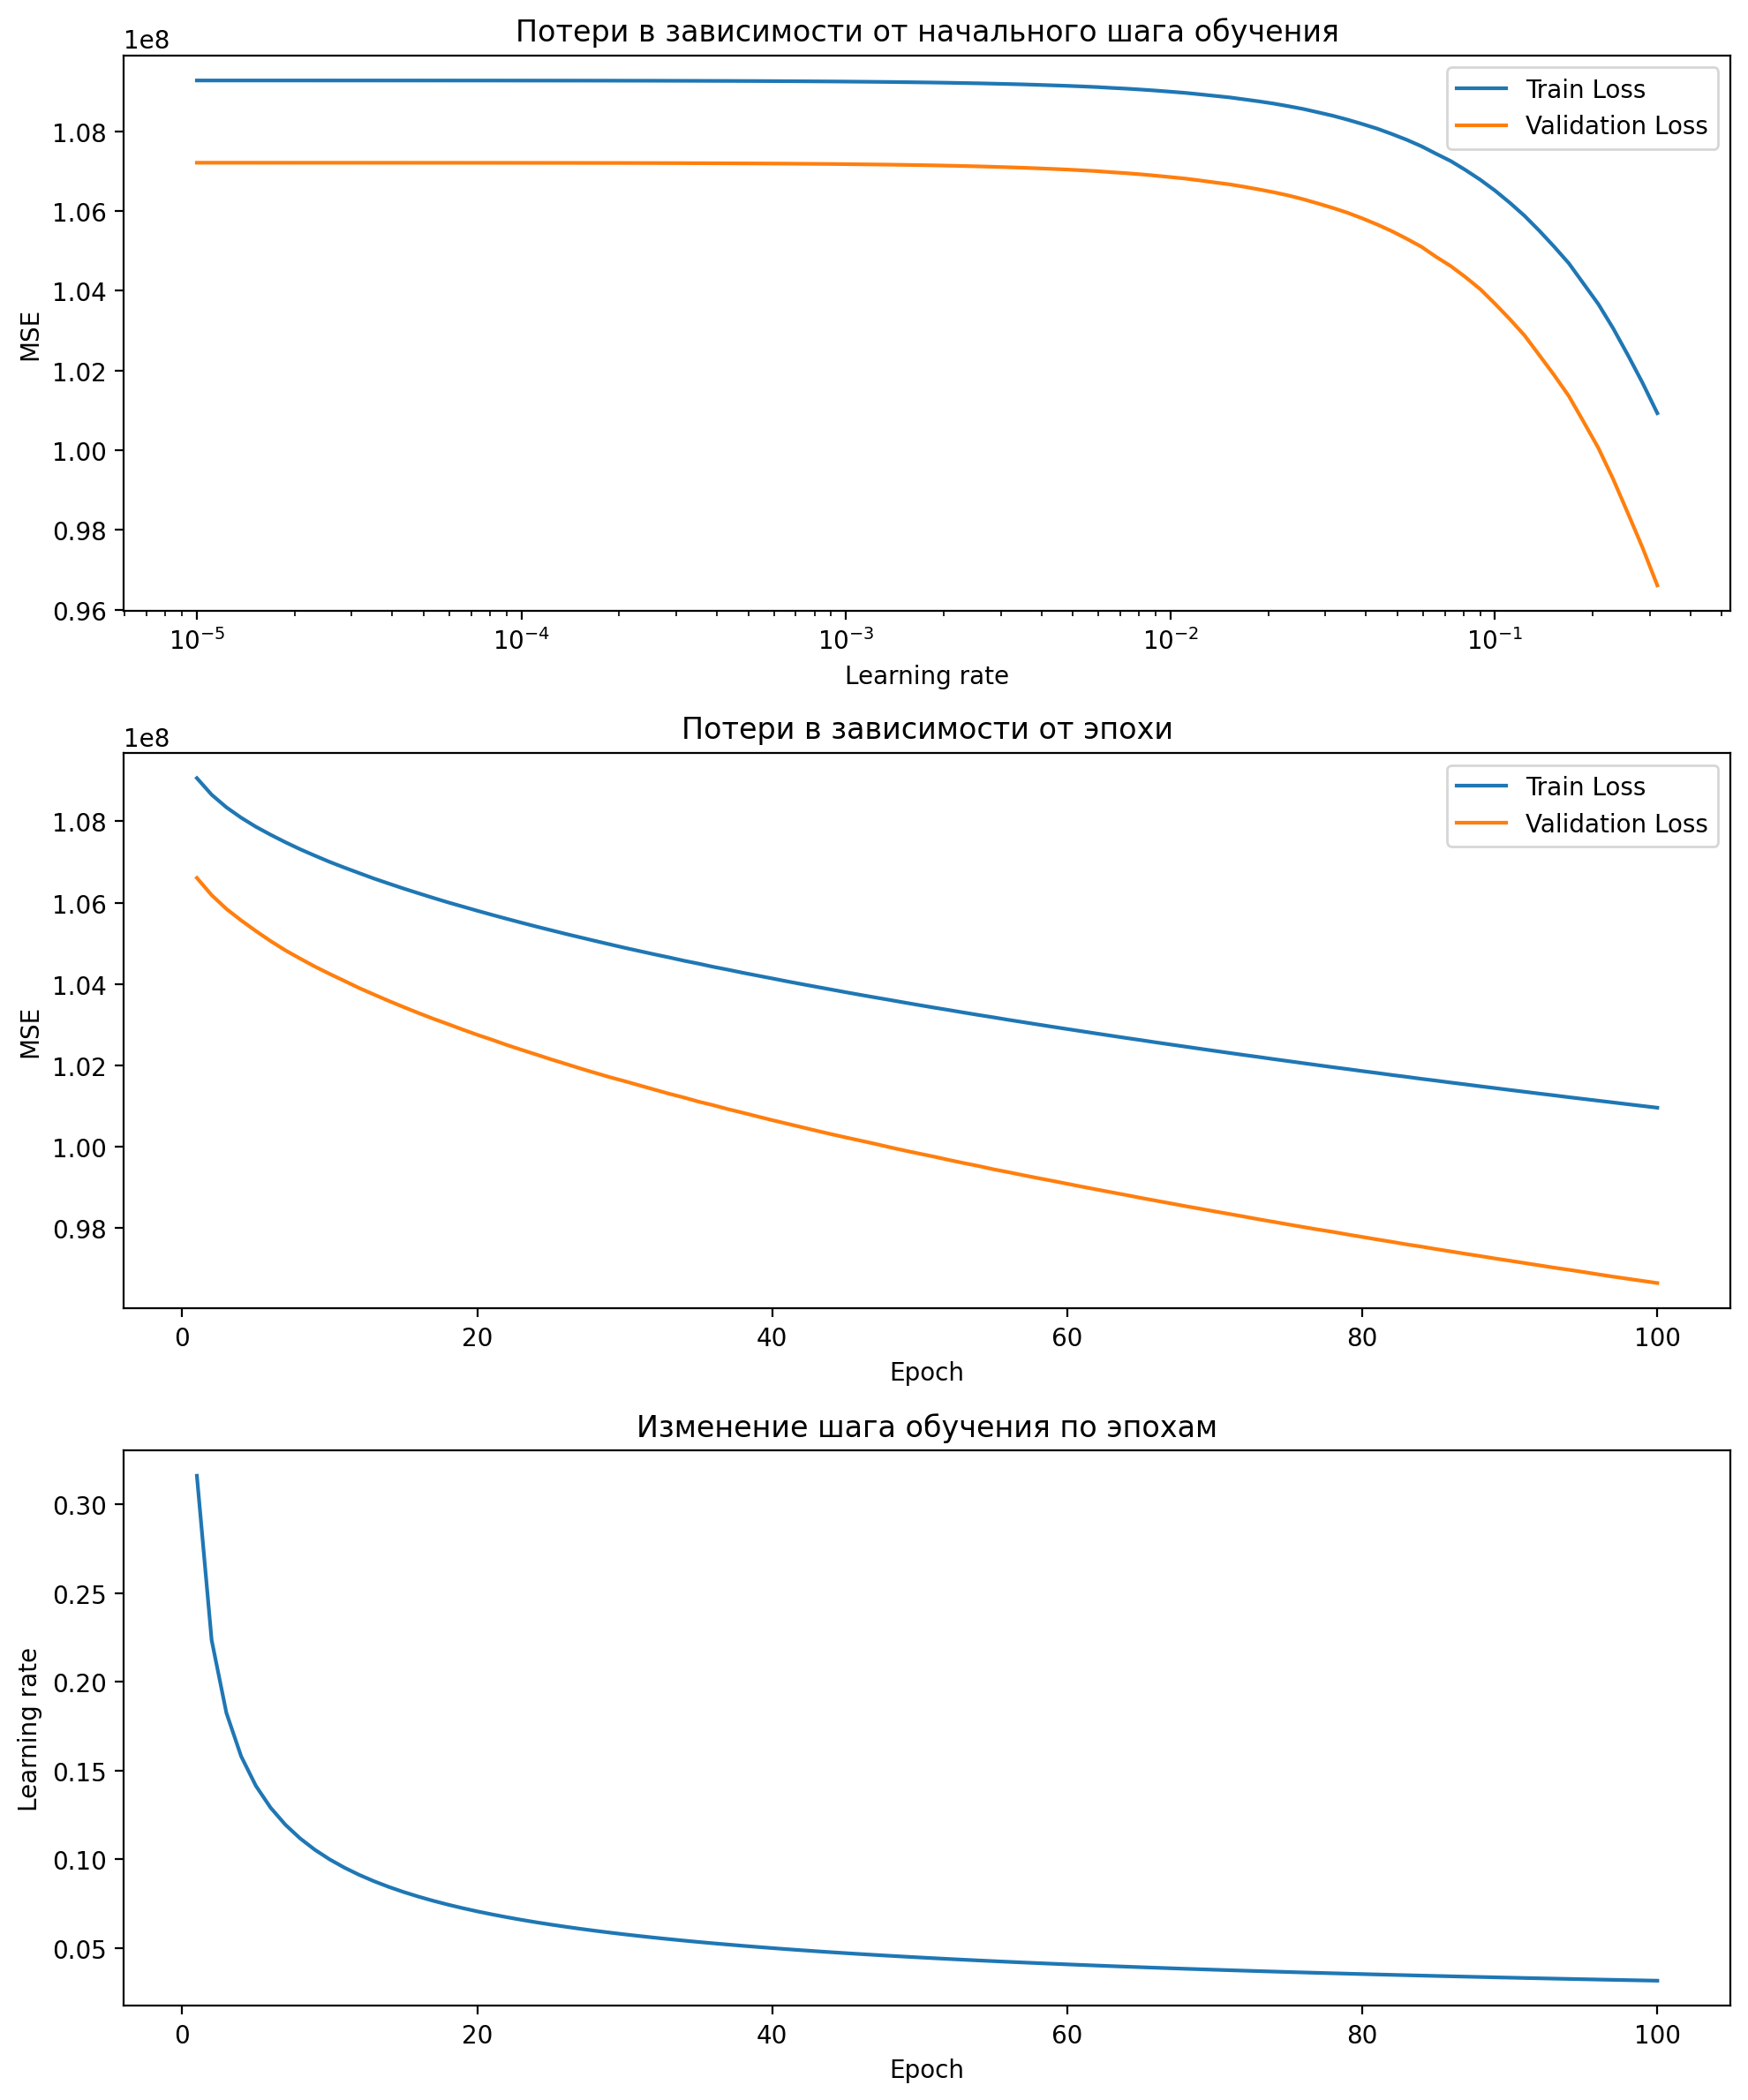

Лучший начальный шаг: 0.31622776601683794
Оптимальное количество эпох: 100
R2 на тестовой выборке: -0.7146
Loss на тестовой выборке: 119570113.7117


In [99]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

lyamdas = np.logspace(-5, -0.5, 100)


class AdamLinearRegressionTimeLr:
    def __init__(
        self,
        features,
        learning_rate=0.001,
        epochs=100,
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.s = s
        self.p = p

        self.weights = torch.zeros(
            features, 1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.bias = torch.zeros(
            1,
            requires_grad=True,
            dtype=torch.float64
        )

        self.m_weights = torch.zeros(
            features, 1,
            dtype=torch.float64
        )

        self.m_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.v_weights = torch.zeros(
            features, 1,
            dtype=torch.float64
        )

        self.v_bias = torch.zeros(
            1,
            dtype=torch.float64
        )

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        X = torch.tensor(
            np.asarray(X),
            dtype=torch.float64
        )

        y = torch.tensor(
            np.asarray(y),
            dtype=torch.float64
        ).view(-1, 1)

        if X_val is not None and y_val is not None:
            X_val = torch.tensor(
                np.asarray(X_val),
                dtype=torch.float64
            )

            y_val = torch.tensor(
                np.asarray(y_val),
                dtype=torch.float64
            ).view(-1, 1)

        num_samples = X.shape[0]

        self.loss_history = []
        self.val_loss_history = []
        self.lr_history = []

        self.m_weights.zero_()
        self.m_bias.zero_()
        self.v_weights.zero_()
        self.v_bias.zero_()

        t = 0

        for epoch in range(self.epochs):

            lr = self.learning_rate * (
                self.s / (self.s + epoch)
            ) ** self.p

            self.lr_history.append(lr)

            indices = torch.randperm(num_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_losses = []

            for i in range(
                0,
                num_samples,
                self.batch_size
            ):
                X_batch = X_shuffled[
                    i:i + self.batch_size
                ]

                y_batch = y_shuffled[
                    i:i + self.batch_size
                ]

                y_pred = (
                    X_batch @ self.weights
                    + self.bias
                )

                mse = torch.mean(
                    (y_pred - y_batch) ** 2
                )

                mse.backward()

                t += 1

                with torch.no_grad():

                    self.m_weights = (
                        self.beta1 * self.m_weights
                        + (1 - self.beta1)
                        * self.weights.grad
                    )

                    self.m_bias = (
                        self.beta1 * self.m_bias
                        + (1 - self.beta1)
                        * self.bias.grad
                    )

                    self.v_weights = (
                        self.beta2 * self.v_weights
                        + (1 - self.beta2)
                        * self.weights.grad ** 2
                    )

                    self.v_bias = (
                        self.beta2 * self.v_bias
                        + (1 - self.beta2)
                        * self.bias.grad ** 2
                    )

                    m_weights_hat = (
                        self.m_weights
                        / (1 - self.beta1 ** t)
                    )

                    m_bias_hat = (
                        self.m_bias
                        / (1 - self.beta1 ** t)
                    )

                    v_weights_hat = (
                        self.v_weights
                        / (1 - self.beta2 ** t)
                    )

                    v_bias_hat = (
                        self.v_bias
                        / (1 - self.beta2 ** t)
                    )

                    self.weights -= (
                        lr
                        * m_weights_hat
                        / (
                            torch.sqrt(v_weights_hat)
                            + self.epsilon
                        )
                    )

                    self.bias -= (
                        lr
                        * m_bias_hat
                        / (
                            torch.sqrt(v_bias_hat)
                            + self.epsilon
                        )
                    )

                    self.weights.grad.zero_()
                    self.bias.grad.zero_()

                epoch_losses.append(
                    mse.item()
                )

            self.loss_history.append(
                np.mean(epoch_losses)
            )

            if X_val is not None and y_val is not None:

                with torch.no_grad():

                    y_val_pred = (
                        X_val @ self.weights
                        + self.bias
                    )

                    val_mse = torch.mean(
                        (y_val_pred - y_val) ** 2
                    )

                    self.val_loss_history.append(
                        val_mse.item()
                    )

    def predict(self, X):
        with torch.no_grad():

            X = torch.tensor(
                np.asarray(X),
                dtype=torch.float64
            )

            return (
                X @ self.weights + self.bias
            ).detach().numpy()


epochs_range = range(10, 101, 10)

epochs_losses_val = []

for epochs in epochs_range:

    model = AdamLinearRegressionTimeLr(
        learning_rate=0.001,
        epochs=epochs,
        features=X_train.shape[1],
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    epochs_losses_val.append(
        model.val_loss_history[-1]
    )


best_epochs = list(epochs_range)[
    np.argmin(epochs_losses_val)
]


losses_train = []
losses_val = []
r2_train = []

for lyamda in lyamdas:

    model = AdamLinearRegressionTimeLr(
        learning_rate=lyamda,
        epochs=best_epochs,
        features=X_train.shape[1],
        batch_size=32,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        s=1,
        p=0.5
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val
    )

    y_train_pred = model.predict(X_train)

    losses_train.append(
        mean_squared_error(
            y_train,
            y_train_pred
        )
    )

    r2_train.append(
        r2_score(
            y_train,
            y_train_pred
        )
    )

    y_val_pred = model.predict(X_val)

    losses_val.append(
        mean_squared_error(
            y_val,
            y_val_pred
        )
    )


best_lyamda = lyamdas[
    np.argmin(losses_val)
]


model = AdamLinearRegressionTimeLr(
    learning_rate=best_lyamda,
    epochs=best_epochs,
    features=X_train.shape[1],
    batch_size=32,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    s=1,
    p=0.5
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val
)


fig, ax = plt.subplots(
    3,
    1,
    figsize=(10, 12),
    dpi=200
)


ax[0].plot(
    lyamdas,
    losses_train,
    label="Train Loss"
)

ax[0].plot(
    lyamdas,
    losses_val,
    label="Validation Loss"
)

ax[0].set_xlabel(
    "Learning rate"
)

ax[0].set_ylabel(
    "MSE"
)

ax[0].set_xscale(
    "log"
)

ax[0].set_title(
    "Потери в зависимости от начального шага обучения"
)

ax[0].legend()


ax[1].plot(
    range(1, model.epochs + 1),
    model.loss_history,
    label="Train Loss"
)

ax[1].plot(
    range(1, model.epochs + 1),
    model.val_loss_history,
    label="Validation Loss"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "MSE"
)

ax[1].set_title(
    "Потери в зависимости от эпохи"
)

ax[1].legend()


ax[2].plot(
    range(1, model.epochs + 1),
    model.lr_history
)

ax[2].set_xlabel(
    "Epoch"
)

ax[2].set_ylabel(
    "Learning rate"
)

ax[2].set_title(
    "Изменение шага обучения по эпохам")


plt.tight_layout()
plt.show()


print(
    f"Лучший начальный шаг: {best_lyamda}"
)

print(
    f"Оптимальное количество эпох: {best_epochs}"
)

print(
    f"R2 на тестовой выборке: "
    f"{r2_score(y_test, model.predict(X_test)):.4f}"
)

print(
    f"Loss на тестовой выборке: "
    f"{mean_squared_error(y_test, model.predict(X_test)):.4f}"
)



14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


models = {
    "Vanilla": vanilla_model,
    "Vanilla TimeLr": vanilla_timelr_model,
    "SGD": sgd_model,
    "SGD TimeLr": sgd_timelr_model,
    "SAG": sag_model,
    "SAG TimeLr": sag_timelr_model,
    "Momentum": momentum_model,
    "Momentum TimeLr": momentum_timelr_model,
    "Adam": adam_model,
    "Adam TimeLr": adam_timelr_model
}


best_steps = {
    "Vanilla": f"{vanilla_model.learning_rate:.6g}",
    "Vanilla TimeLr": f"{vanilla_timelr_model.learning_rate:.6g} * (1 / (1 + epoch))^0.5",
    "SGD": f"{sgd_model.learning_rate:.6g}",
    "SGD TimeLr": f"{sgd_timelr_model.learning_rate:.6g} * (1 / (1 + epoch))^0.5",
    "SAG": f"{sag_model.learning_rate:.6g}",
    "SAG TimeLr": f"{sag_timelr_model.learning_rate:.6g} * (1 / (1 + epoch))^0.5",
    "Momentum": f"{momentum_model.learning_rate:.6g}",
    "Momentum TimeLr": f"{momentum_timelr_model.learning_rate:.6g} * (1 / (1 + epoch))^0.5",
    "Adam": f"{adam_model.learning_rate:.6g}",
    "Adam TimeLr": f"{adam_timelr_model.learning_rate:.6g} * (1 / (1 + epoch))^0.5"
}


rows = []

for name, model in models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    loss_train = mean_squared_error(
        y_train,
        y_train_pred
    )

    loss_test = mean_squared_error(
        y_test,
        y_test_pred
    )

    r2_train = r2_score(
        y_train,
        y_train_pred
    )

    r2_test = r2_score(
        y_test,
        y_test_pred
    )

    if hasattr(model, "batch_size"):
        iterations_test = int(
            np.ceil(
                len(X_test) / model.batch_size
            )
        )
    else:
        iterations_test = 1

    rows.append({
        "Название метода": name,
        "Лучший шаг": best_steps[name],
        "Loss_train": loss_train,
        "Loss_test": loss_test,
        "R^2 train": r2_train,
        "R^2 test": r2_test,
        "Число итераций на test": iterations_test
    })


results = pd.DataFrame(rows)

results["Loss_train"] = results["Loss_train"].round(6)
results["Loss_test"] = results["Loss_test"].round(6)
results["R^2 train"] = results["R^2 train"].round(6)
results["R^2 test"] = results["R^2 test"].round(6)

results

NameError: name 'vanilla_model' is not defined

15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?